In [1]:
# Cell 0 | 设置锁定10点补充验证环境、路径和冻结文件身份

import hashlib
import json
import os
import random
import sys
import warnings
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import Image, display
from rdkit import Chem, RDLogger
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
RDLogger.DisableLog("rdApp.*")


def find_project_root(start_path="."):
    current = Path(start_path).resolve()

    for _ in range(20):
        if (
            (current / "data").exists()
            and (current / "notebooks").exists()
        ):
            return current

        if current.parent == current:
            break

        current = current.parent

    raise FileNotFoundError(
        "未找到项目根目录。请确认当前Notebook位于：\n"
        r"D:\jupyter\IL_ML_Project\notebooks"
    )


def calculate_sha256(path):
    digest = hashlib.sha256()

    with Path(path).open("rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


def array_sha256(array):
    contiguous = np.ascontiguousarray(
        np.asarray(array)
    )

    return hashlib.sha256(
        contiguous.tobytes()
    ).hexdigest()


def read_json(path):
    with Path(path).open(
        "r",
        encoding="utf-8",
    ) as file:
        return json.load(file)


def read_csv_robust(path, **kwargs):
    last_error = None

    for encoding in [
        "utf-8-sig",
        "utf-8",
        "gb18030",
    ]:
        try:
            dataframe = pd.read_csv(
                path,
                encoding=encoding,
                **kwargs,
            )

            dataframe.columns = (
                dataframe.columns
                .astype(str)
                .str.replace(
                    "\ufeff",
                    "",
                    regex=False,
                )
                .str.strip()
            )

            return dataframe

        except UnicodeDecodeError as error:
            last_error = error

    raise last_error


def to_jsonable(value):
    if isinstance(value, dict):
        return {
            str(key): to_jsonable(item)
            for key, item in value.items()
        }

    if isinstance(value, (list, tuple)):
        return [
            to_jsonable(item)
            for item in value
        ]

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, np.integer):
        return int(value)

    if isinstance(value, np.floating):
        return float(value)

    if isinstance(value, Path):
        return str(value)

    return value


def save_json_atomic(data, output_path):
    output_path = Path(output_path)

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    temporary_path = output_path.with_name(
        output_path.name + ".tmp"
    )

    with temporary_path.open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            to_jsonable(data),
            file,
            ensure_ascii=False,
            indent=2,
        )

    os.replace(
        temporary_path,
        output_path,
    )


def save_csv_atomic(dataframe, output_path):
    output_path = Path(output_path)

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    temporary_path = output_path.with_name(
        output_path.name + ".tmp"
    )

    dataframe.to_csv(
        temporary_path,
        index=False,
        encoding="utf-8-sig",
    )

    os.replace(
        temporary_path,
        output_path,
    )


def save_npy_atomic(array, output_path):
    output_path = Path(output_path)

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    temporary_path = output_path.with_name(
        output_path.name + ".tmp"
    )

    with temporary_path.open("wb") as file:
        np.save(
            file,
            np.asarray(array),
            allow_pickle=False,
        )

    os.replace(
        temporary_path,
        output_path,
    )


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


PROJECT_ROOT = find_project_root(
    Path.cwd()
)

EXPERIMENT_ROOT = (
    PROJECT_ROOT
    / "small_paper_data"
    / "viscosity_10point_holdout"
)

PIPELINE_ROOT = (
    EXPERIMENT_ROOT
    / "outputs"
    / "model_training_3models_cv_no_leakage_2splits"
)

FINAL_FREEZE_ROOT = (
    PIPELINE_ROOT
    / "final_two_model_freeze"
)

OLD_EXTERNAL_ROOT = (
    EXPERIMENT_ROOT
    / "outputs"
    / "external_holdout_10point_3models"
)

HOLDOUT_PATH = (
    EXPERIMENT_ROOT
    / "validation"
    / "holdout_10_points"
    / "holdout_10_points.csv"
)

ML_READY_PATH = (
    EXPERIMENT_ROOT
    / "ml_ready"
    / "ml_ready_A.csv"
)

MPNN_MODEL_PATH = (
    EXPERIMENT_ROOT
    / "models"
    / "mpnn_feature_extractors"
    / "mpnn_feature_extractor_viscosity.pt"
)

MPNN_TP_SCALER_PATH = (
    EXPERIMENT_ROOT
    / "models"
    / "mpnn_feature_extractors"
    / "tp_scaler_viscosity.joblib"
)

MPNN_METADATA_PATH = (
    EXPERIMENT_ROOT
    / "models"
    / "mpnn_feature_extractors"
    / "mpnn_feature_extractor_viscosity_metadata.json"
)

FINAL_SCALER_PATH = (
    FINAL_FREEZE_ROOT
    / "scalers"
    / "final_downstream_feature_scaler.joblib"
)

FINAL_LGBM_PATH = (
    FINAL_FREEZE_ROOT
    / "models"
    / "final_LightGBM_viscosity.joblib"
)

FINAL_TRANSFORMER_PATH = (
    FINAL_FREEZE_ROOT
    / "models"
    / "final_Transformer_viscosity.pt"
)

FINAL_FREEZE_MANIFEST_PATH = (
    FINAL_FREEZE_ROOT
    / "logs"
    / "final_two_model_freeze_manifest.json"
)

OUT_ROOT = (
    EXPERIMENT_ROOT
    / "outputs"
    / "external_holdout_10point_LGBM_Transformer_final"
)

FEATURE_DIR = OUT_ROOT / "features"
RESULT_DIR = OUT_ROOT / "results"
LOG_DIR = OUT_ROOT / "logs"
FIGURE_ROOT = OUT_ROOT / "figures"

PNG_DIR = FIGURE_ROOT / "PNG"
SVG_DIR = FIGURE_ROOT / "SVG"
PDF_DIR = FIGURE_ROOT / "PDF"
CSV_DIR = FIGURE_ROOT / "CSV"

for folder in [
    OUT_ROOT,
    FEATURE_DIR,
    RESULT_DIR,
    LOG_DIR,
    FIGURE_ROOT,
    PNG_DIR,
    SVG_DIR,
    PDF_DIR,
    CSV_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

output_text = str(
    OUT_ROOT.resolve()
).lower()

if (
    "small_paper_data"
    not in output_text
    or
    "viscosity_10point_holdout"
    not in output_text
):
    raise RuntimeError(
        "外部10点输出目录异常，已停止运行。"
    )

EXPECTED_HASHES = {
    "holdout_10_points": (
        "af45197ffdfb5feb955cd882431e1f1fb"
        "0b8819eaead5adede73735938b13c4e"
    ),
    "mpnn_model": (
        "b6ecd1355f103f1446e0fd2239182949"
        "54a4beee1f4c818b726936814b276bfe"
    ),
    "mpnn_tp_scaler": (
        "f01c08fe0e3b7062c7a1f4d05e5adb87"
        "278dfbaf3f29fbf234342bf49c33fbbe"
    ),
    "final_downstream_scaler": (
        "b51e21e80c03f71f3749a0aad3d1c0b2"
        "cf11b2e87fd3323971e90f689887ecb4"
    ),
    "final_LightGBM": (
        "29d4cbcefa0896225f413ac397cb85cf"
        "807185a74b4340d0f9da6f86b69abb1b"
    ),
    "final_Transformer": (
        "6e03e4dd0e5b9342a1a776770e76abee"
        "252cea4261f56b23e7a7dfcdbf91ad70"
    ),
}

required_paths = [
    HOLDOUT_PATH,
    ML_READY_PATH,
    MPNN_MODEL_PATH,
    MPNN_TP_SCALER_PATH,
    MPNN_METADATA_PATH,
    FINAL_SCALER_PATH,
    FINAL_LGBM_PATH,
    FINAL_TRANSFORMER_PATH,
    FINAL_FREEZE_MANIFEST_PATH,
    OLD_EXTERNAL_ROOT,
]

missing_paths = [
    path
    for path in required_paths
    if not Path(path).exists()
]

if missing_paths:
    raise FileNotFoundError(
        "缺少必要输入：\n"
        + "\n".join(
            map(str, missing_paths)
        )
    )

actual_hashes = {
    "holdout_10_points": calculate_sha256(
        HOLDOUT_PATH
    ),
    "mpnn_model": calculate_sha256(
        MPNN_MODEL_PATH
    ),
    "mpnn_tp_scaler": calculate_sha256(
        MPNN_TP_SCALER_PATH
    ),
    "final_downstream_scaler": calculate_sha256(
        FINAL_SCALER_PATH
    ),
    "final_LightGBM": calculate_sha256(
        FINAL_LGBM_PATH
    ),
    "final_Transformer": calculate_sha256(
        FINAL_TRANSFORMER_PATH
    ),
}

for role, expected_hash in EXPECTED_HASHES.items():
    if actual_hashes[role] != expected_hash:
        raise RuntimeError(
            f"{role}的SHA256与冻结版本不一致：\n"
            f"actual   = {actual_hashes[role]}\n"
            f"expected = {expected_hash}"
        )

freeze_manifest = read_json(
    FINAL_FREEZE_MANIFEST_PATH
)

if (
    freeze_manifest.get("status")
    != "final_two_model_freeze_completed"
):
    raise RuntimeError(
        "最终两模型冻结manifest状态不正确。"
    )

if (
    freeze_manifest
    .get("formal_selection", {})
    .get("final_application_model")
    != "LightGBM"
):
    raise RuntimeError(
        "冻结manifest未将LightGBM登记为最终应用模型。"
    )

if (
    freeze_manifest
    .get("usage_lock", {})
    .get("virtual_IL_prediction_model")
    != "LightGBM"
):
    raise RuntimeError(
        "冻结manifest中的虚拟IL预测模型不是LightGBM。"
    )

if bool(
    freeze_manifest
    .get("usage_lock", {})
    .get(
        "external_10point_may_change_final_model",
        True,
    )
):
    raise RuntimeError(
        "冻结manifest允许外部10点重新选模，已停止运行。"
    )

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

RUN_CODE_VERSION = (
    "18_locked10_LGBM_Transformer_"
    "supplementary_validation_v1_20260725"
)

EXPECTED_EXTERNAL_ROWS = 10
EXPECTED_FEATURE_DIM = 130

LGBM_COLOR = "#F89030"
TRANSFORMER_COLOR = "#72A66A"
EXPERIMENTAL_COLOR = "#222222"

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300

seed_everything(42)

print("=" * 108)
print(
    "Cell 0 锁定10点补充验证环境和"
    "冻结文件身份检查通过 ✓"
)
print("=" * 108)

print("python                         =", sys.executable)
print("torch                          =", torch.__version__)
print("device                         =", DEVICE)
print("PROJECT_ROOT                   =", PROJECT_ROOT)
print("EXPERIMENT_ROOT                =", EXPERIMENT_ROOT)
print("HOLDOUT_PATH                   =", HOLDOUT_PATH)
print("FINAL_LGBM_PATH                =", FINAL_LGBM_PATH)
print("FINAL_TRANSFORMER_PATH         =", FINAL_TRANSFORMER_PATH)
print("FINAL_SCALER_PATH              =", FINAL_SCALER_PATH)
print("OUT_ROOT                       =", OUT_ROOT)
print("final application model        =", "LightGBM")
print("supplementary control model    =", "Transformer")
print("external labels read           =", False)
print("model training executed        =", False)
print("parameter tuning executed      =", False)

Cell 0 锁定10点补充验证环境和冻结文件身份检查通过 ✓
python                         = D:\conda\envs\rdkit-env\python.exe
torch                          = 2.2.1+cpu
device                         = cpu
PROJECT_ROOT                   = D:\jupyter\IL_ML_Project
EXPERIMENT_ROOT                = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout
HOLDOUT_PATH                   = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\validation\holdout_10_points\holdout_10_points.csv
FINAL_LGBM_PATH                = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\model_training_3models_cv_no_leakage_2splits\final_two_model_freeze\models\final_LightGBM_viscosity.joblib
FINAL_TRANSFORMER_PATH         = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\model_training_3models_cv_no_leakage_2splits\final_two_model_freeze\models\final_Transformer_viscosity.pt
FINAL_SCALER_PATH              = D:\jupyter\IL_ML_Project\small_paper_data\vis

In [2]:
# Cell 1 | 无标签读取锁定10点输入并核对开发集隔离关系

def resolve_single_column(
    available_columns,
    candidates,
    role,
):
    matches = [
        column
        for column in candidates
        if column in available_columns
    ]

    if len(matches) == 0:
        raise KeyError(
            f"未找到{role}字段。候选字段：{candidates}"
        )

    if len(matches) > 1:
        raise RuntimeError(
            f"{role}字段存在歧义：{matches}"
        )

    return matches[0]


holdout_header = read_csv_robust(
    HOLDOUT_PATH,
    nrows=0,
)

holdout_columns = list(
    holdout_header.columns
)

HOLDOUT_COLUMN_MAP = {
    "holdout_id": resolve_single_column(
        holdout_columns,
        [
            "holdout_id",
            "Holdout_ID",
            "external_id",
            "point_id",
        ],
        "锁定点编号",
    ),
    "cation_smiles": resolve_single_column(
        holdout_columns,
        [
            "cation_smiles",
            "Cation_SMILES",
        ],
        "阳离子SMILES",
    ),
    "anion_smiles": resolve_single_column(
        holdout_columns,
        [
            "anion_smiles",
            "Anion_SMILES",
        ],
        "阴离子SMILES",
    ),
    "T_K": resolve_single_column(
        holdout_columns,
        [
            "T_K",
            "T_rep",
            "temperature_K",
            "Temperature_K",
        ],
        "温度",
    ),
    "P_bar": resolve_single_column(
        holdout_columns,
        [
            "P_bar",
            "P_rep",
            "pressure_bar",
            "Pressure_bar",
        ],
        "压力",
    ),
}

input_usecols = list(
    HOLDOUT_COLUMN_MAP.values()
)

holdout_input_raw = read_csv_robust(
    HOLDOUT_PATH,
    usecols=input_usecols,
)

holdout_input = (
    holdout_input_raw
    .rename(
        columns={
            source: target
            for target, source
            in HOLDOUT_COLUMN_MAP.items()
        }
    )
    .copy()
)

holdout_input["holdout_id"] = (
    holdout_input["holdout_id"]
    .astype(str)
    .str.strip()
)

holdout_input["cation_smiles"] = (
    holdout_input["cation_smiles"]
    .astype(str)
    .str.strip()
)

holdout_input["anion_smiles"] = (
    holdout_input["anion_smiles"]
    .astype(str)
    .str.strip()
)

for column in ["T_K", "P_bar"]:
    holdout_input[column] = pd.to_numeric(
        holdout_input[column],
        errors="raise",
    )

if len(holdout_input) != EXPECTED_EXTERNAL_ROWS:
    raise RuntimeError(
        f"锁定点数量为{len(holdout_input)}，"
        f"预期为{EXPECTED_EXTERNAL_ROWS}。"
    )

if holdout_input["holdout_id"].duplicated().any():
    raise RuntimeError(
        "锁定10点编号存在重复。"
    )

if holdout_input.isna().any().any():
    raise RuntimeError(
        "锁定10点无标签输入字段存在缺失值。"
    )


def canonical_smiles(smiles):
    molecule = Chem.MolFromSmiles(
        str(smiles).strip()
    )

    if molecule is None:
        return None

    return Chem.MolToSmiles(
        molecule,
        canonical=True,
    )


holdout_input["cation_smiles_canon"] = (
    holdout_input["cation_smiles"]
    .map(canonical_smiles)
)

holdout_input["anion_smiles_canon"] = (
    holdout_input["anion_smiles"]
    .map(canonical_smiles)
)

if (
    holdout_input[
        [
            "cation_smiles_canon",
            "anion_smiles_canon",
        ]
    ]
    .isna()
    .any()
    .any()
):
    raise RuntimeError(
        "锁定10点中存在RDKit无法解析的SMILES。"
    )

holdout_input["IL_key_canon"] = (
    holdout_input["cation_smiles_canon"]
    + "||"
    + holdout_input["anion_smiles_canon"]
)

development_identity = read_csv_robust(
    ML_READY_PATH,
    usecols=[
        "IL_key",
        "cation_smiles",
        "anion_smiles",
        "T_rep",
        "P_rep",
    ],
)

development_identity["cation_smiles_canon"] = (
    development_identity["cation_smiles"]
    .astype(str)
    .str.strip()
    .map(canonical_smiles)
)

development_identity["anion_smiles_canon"] = (
    development_identity["anion_smiles"]
    .astype(str)
    .str.strip()
    .map(canonical_smiles)
)

development_identity["IL_key_canon"] = (
    development_identity["cation_smiles_canon"]
    + "||"
    + development_identity["anion_smiles_canon"]
)

development_identity["T_rep"] = pd.to_numeric(
    development_identity["T_rep"],
    errors="raise",
)

development_identity["P_rep"] = pd.to_numeric(
    development_identity["P_rep"],
    errors="raise",
)

audit_records = []

for _, row in holdout_input.iterrows():
    same_il = development_identity.loc[
        development_identity["IL_key_canon"]
        == row["IL_key_canon"]
    ].copy()

    exact_condition_mask = (
        np.isclose(
            same_il["T_rep"].to_numpy(dtype=float),
            float(row["T_K"]),
            atol=1e-8,
            rtol=0.0,
        )
        &
        np.isclose(
            same_il["P_rep"].to_numpy(dtype=float),
            float(row["P_bar"]),
            atol=1e-8,
            rtol=0.0,
        )
    )

    exact_condition_overlap = int(
        exact_condition_mask.sum()
    )

    if len(same_il) > 0:
        temperature_within_range = bool(
            float(row["T_K"])
            >= float(same_il["T_rep"].min())
            and
            float(row["T_K"])
            <= float(same_il["T_rep"].max())
        )

        pressure_seen = bool(
            np.isclose(
                same_il["P_rep"].to_numpy(dtype=float),
                float(row["P_bar"]),
                atol=1e-8,
                rtol=0.0,
            ).any()
        )

    else:
        temperature_within_range = False
        pressure_seen = False

    audit_records.append(
        {
            "holdout_id": row["holdout_id"],
            "IL_key_canon": row["IL_key_canon"],
            "T_K": row["T_K"],
            "P_bar": row["P_bar"],
            "IL_seen_in_development_data": bool(
                len(same_il) > 0
            ),
            "Development_rows_for_same_IL": int(
                len(same_il)
            ),
            "Exact_IL_T_P_overlap": (
                exact_condition_overlap
            ),
            "Temperature_within_same_IL_"
            "development_range": (
                temperature_within_range
            ),
            "Pressure_seen_for_same_IL": (
                pressure_seen
            ),
            "External_label_read_in_Cell_1": False,
        }
    )

holdout_identity_audit = pd.DataFrame(
    audit_records
)

if not holdout_identity_audit[
    "IL_seen_in_development_data"
].all():
    raise RuntimeError(
        "存在开发集中完全未见过的锁定IL。"
    )

if (
    holdout_identity_audit[
        "Exact_IL_T_P_overlap"
    ]
    .sum()
    != 0
):
    raise RuntimeError(
        "锁定10点中存在与开发集完全相同的"
        "IL+T+P记录。"
    )

HOLDOUT_INPUT_PATH = (
    RESULT_DIR
    / "locked10_unlabeled_input.csv"
)

HOLDOUT_IDENTITY_AUDIT_PATH = (
    RESULT_DIR
    / "locked10_identity_and_isolation_audit.csv"
)

HOLDOUT_INPUT_MANIFEST_PATH = (
    LOG_DIR
    / "locked10_unlabeled_input_manifest.json"
)

save_csv_atomic(
    holdout_input,
    HOLDOUT_INPUT_PATH,
)

save_csv_atomic(
    holdout_identity_audit,
    HOLDOUT_IDENTITY_AUDIT_PATH,
)

input_manifest = {
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "run_code_version": RUN_CODE_VERSION,
    "status": (
        "locked10_unlabeled_inputs_verified"
    ),
    "holdout_file": str(HOLDOUT_PATH),
    "holdout_file_sha256": calculate_sha256(
        HOLDOUT_PATH
    ),
    "column_mapping": HOLDOUT_COLUMN_MAP,
    "rows": len(holdout_input),
    "unique_holdout_ids": int(
        holdout_input["holdout_id"].nunique()
    ),
    "unique_ILs": int(
        holdout_input["IL_key_canon"].nunique()
    ),
    "all_ILs_seen_in_development_data": True,
    "exact_IL_T_P_overlap_rows": 0,
    "interpretation": (
        "seen_IL_new_condition_locked_"
        "supplementary_validation"
    ),
    "external_label_columns_read": False,
    "external_label_values_read": False,
    "outputs": {
        "unlabeled_input": str(
            HOLDOUT_INPUT_PATH
        ),
        "identity_audit": str(
            HOLDOUT_IDENTITY_AUDIT_PATH
        ),
        "input_manifest": str(
            HOLDOUT_INPUT_MANIFEST_PATH
        ),
    },
}

save_json_atomic(
    input_manifest,
    HOLDOUT_INPUT_MANIFEST_PATH,
)

HOLDOUT_INPUT_DF = holdout_input.copy()

print("=" * 108)
print(
    "Cell 1 锁定10点无标签输入和"
    "隔离关系核对通过 ✓"
)
print("=" * 108)

print("locked external rows               =", len(HOLDOUT_INPUT_DF))
print(
    "unique locked ILs                  =",
    HOLDOUT_INPUT_DF[
        "IL_key_canon"
    ].nunique(),
)
print(
    "all ILs seen in development        =",
    True,
)
print(
    "exact IL+T+P overlap               =",
    int(
        holdout_identity_audit[
            "Exact_IL_T_P_overlap"
        ].sum()
    ),
)
print("external label values read          =", False)
print("unlabeled input                     =", HOLDOUT_INPUT_PATH)
print("identity audit                      =", HOLDOUT_IDENTITY_AUDIT_PATH)
print("input manifest                      =", HOLDOUT_INPUT_MANIFEST_PATH)

display(
    holdout_identity_audit
)

Cell 1 锁定10点无标签输入和隔离关系核对通过 ✓
locked external rows               = 10
unique locked ILs                  = 10
all ILs seen in development        = True
exact IL+T+P overlap               = 0
external label values read          = False
unlabeled input                     = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\results\locked10_unlabeled_input.csv
identity audit                      = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\results\locked10_identity_and_isolation_audit.csv
input manifest                      = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\logs\locked10_unlabeled_input_manifest.json


,holdout_id,IL_key_canon,T_K,P_bar,IL_seen_in_development_data,Development_rows_for_same_IL,Exact_IL_T_P_overlap,Temperature_within_same_IL_development_range,Pressure_seen_for_same_IL,External_label_read_in_Cell_1
0,H01,CCCC[n+]1cccc(C)c1||N#CC(=C=[N-])C#N,313.15,1.01325,True,9,0,True,True,False
1,H02,CCOCC[n+]1ccccc1||O=S(=O)([N-]S(=O)(=O)C(F)(F)...,313.15,1.01325,True,8,0,True,True,False
2,H03,C[n+]1ccn(CCCl)c1||N#C[N-]C#N,328.15,1.01325,True,14,0,True,True,False
3,H04,CCCCCCn1cn[n+](CCCCS(=O)(=O)O)c1||O=S(=O)([O-]...,318.15,1.00000,True,10,0,True,True,False
4,H05,CCCCCCCCCC[P+](CCCC)(CCCC)CCCC||O=S(=O)([N-]S(...,328.10,1.01325,True,7,0,True,True,False
5,H06,CCCCCC[N+](C)(C)C(C)C||O=S(=O)([N-]S(=O)(=O)C(...,308.10,1.01325,True,12,0,True,True,False
6,H07,CCCCCCCCn1cc[n+](C)c1||N#CC(=C=[N-])C#N,283.20,1.00000,True,49,0,True,True,False
7,H08,CCCCC[P+](CC)(CC)CC||O=S(=O)([N-]S(=O)(=O)C(F)...,303.15,1.01325,True,12,0,True,True,False
8,H09,CCCCn1cc[n+](C)c1||NC(CO)C(=O)[O-],318.15,1.01325,True,8,0,True,True,False
9,H10,CCCCCCCC[N+]1(C)CCOCC1||CC(=O)N[C@@H](C)C(=O)[O-],308.15,1.01325,True,4,0,True,True,False


In [3]:
# Cell 2 | 核对并固定锁定10点的无标签MPNN表征

candidate_feature_records = []

for candidate_path in OLD_EXTERNAL_ROOT.rglob("*.npy"):
    try:
        candidate_array = np.load(
            candidate_path,
            mmap_mode="r",
            allow_pickle=False,
        )

        if (
            candidate_array.shape
            == (
                EXPECTED_EXTERNAL_ROWS,
                EXPECTED_FEATURE_DIM,
            )
        ):
            candidate_values = np.asarray(
                candidate_array,
                dtype=np.float32,
            )

            if np.isfinite(
                candidate_values
            ).all():
                candidate_feature_records.append(
                    {
                        "Path": candidate_path,
                        "File_SHA256": calculate_sha256(
                            candidate_path
                        ),
                        "Array_SHA256": array_sha256(
                            candidate_values
                        ),
                        "Shape": candidate_values.shape,
                    }
                )

    except Exception:
        continue

if len(candidate_feature_records) == 0:
    raise FileNotFoundError(
        "在旧外部10点输出目录中未找到"
        "形状为(10, 130)的无标签MPNN特征文件。\n"
        f"检查目录：{OLD_EXTERNAL_ROOT}"
    )

unique_array_hashes = sorted(
    {
        record["Array_SHA256"]
        for record in candidate_feature_records
    }
)

if len(unique_array_hashes) != 1:
    candidate_display = pd.DataFrame(
        [
            {
                "Path": str(record["Path"]),
                "File_SHA256": record[
                    "File_SHA256"
                ],
                "Array_SHA256": record[
                    "Array_SHA256"
                ],
            }
            for record in candidate_feature_records
        ]
    )

    display(candidate_display)

    raise RuntimeError(
        "检测到多份内容不同的10×130外部特征，"
        "无法唯一确定，应停止运行。"
    )

candidate_feature_records = sorted(
    candidate_feature_records,
    key=lambda record: (
        len(str(record["Path"])),
        str(record["Path"]),
    ),
)

SOURCE_EXTERNAL_FEATURE_PATH = (
    candidate_feature_records[0]["Path"]
)

external_features_raw = np.load(
    SOURCE_EXTERNAL_FEATURE_PATH,
    allow_pickle=False,
).astype(
    np.float32
)

if (
    external_features_raw.shape
    != (
        EXPECTED_EXTERNAL_ROWS,
        EXPECTED_FEATURE_DIM,
    )
):
    raise RuntimeError(
        "锁定10点MPNN表征形状错误。"
    )

if not np.isfinite(
    external_features_raw
).all():
    raise RuntimeError(
        "锁定10点MPNN表征存在NaN或无穷值。"
    )

tp_scaler = joblib.load(
    MPNN_TP_SCALER_PATH
)

tp_input = (
    HOLDOUT_INPUT_DF[
        ["T_K", "P_bar"]
    ]
    .to_numpy(
        dtype=np.float64
    )
)

tp_scaled_expected = (
    tp_scaler
    .transform(
        tp_input
    )
    .astype(
        np.float32
    )
)

if (
    tp_scaled_expected.shape
    != (
        EXPECTED_EXTERNAL_ROWS,
        2,
    )
):
    raise RuntimeError(
        "温压标准化结果形状错误。"
    )

tp_scaled_in_feature = (
    external_features_raw[
        :,
        -2:
    ]
)

tp_alignment_max_error = float(
    np.max(
        np.abs(
            tp_scaled_in_feature
            - tp_scaled_expected
        )
    )
)

if tp_alignment_max_error > 1e-6:
    raise RuntimeError(
        "外部10点MPNN特征最后两维与"
        "当前温压标准化器结果不一致：\n"
        f"max_error={tp_alignment_max_error}"
    )

graph_audit_candidates = sorted(
    OLD_EXTERNAL_ROOT.rglob(
        "*graph*audit*.csv"
    )
)

graph_audit_path = (
    graph_audit_candidates[0]
    if len(graph_audit_candidates) > 0
    else None
)

graph_audit_id_matched = None

if graph_audit_path is not None:
    graph_audit_df = read_csv_robust(
        graph_audit_path
    )

    id_candidates = [
        column
        for column in [
            "holdout_id",
            "Holdout_ID",
            "external_id",
            "point_id",
        ]
        if column in graph_audit_df.columns
    ]

    if len(id_candidates) == 1:
        graph_ids = (
            graph_audit_df[
                id_candidates[0]
            ]
            .astype(str)
            .str.strip()
            .tolist()
        )

        expected_ids = (
            HOLDOUT_INPUT_DF[
                "holdout_id"
            ]
            .astype(str)
            .tolist()
        )

        graph_audit_id_matched = (
            graph_ids == expected_ids
        )

        if not graph_audit_id_matched:
            raise RuntimeError(
                "旧图结构审计文件中的锁定点顺序"
                "与当前10点顺序不一致。"
            )

LOCKED10_FEATURE_PATH = (
    FEATURE_DIR
    / "locked10_mpnn_features_130d.npy"
)

LOCKED10_FEATURE_AUDIT_PATH = (
    RESULT_DIR
    / "locked10_mpnn_feature_alignment_audit.csv"
)

LOCKED10_FEATURE_MANIFEST_PATH = (
    LOG_DIR
    / "locked10_mpnn_feature_manifest.json"
)

save_npy_atomic(
    external_features_raw,
    LOCKED10_FEATURE_PATH,
)

feature_alignment_audit = pd.DataFrame(
    {
        "holdout_id": (
            HOLDOUT_INPUT_DF[
                "holdout_id"
            ].to_numpy()
        ),
        "T_K": (
            HOLDOUT_INPUT_DF[
                "T_K"
            ].to_numpy()
        ),
        "P_bar": (
            HOLDOUT_INPUT_DF[
                "P_bar"
            ].to_numpy()
        ),
        "Feature_T_scaled": (
            tp_scaled_in_feature[:, 0]
        ),
        "Expected_T_scaled": (
            tp_scaled_expected[:, 0]
        ),
        "Feature_P_scaled": (
            tp_scaled_in_feature[:, 1]
        ),
        "Expected_P_scaled": (
            tp_scaled_expected[:, 1]
        ),
        "TP_alignment_passed": (
            np.all(
                np.isclose(
                    tp_scaled_in_feature,
                    tp_scaled_expected,
                    atol=1e-6,
                    rtol=0.0,
                ),
                axis=1,
            )
        ),
        "External_label_read_in_Cell_2": False,
    }
)

save_csv_atomic(
    feature_alignment_audit,
    LOCKED10_FEATURE_AUDIT_PATH,
)

feature_manifest = {
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "run_code_version": RUN_CODE_VERSION,
    "status": (
        "locked10_mpnn_features_verified"
    ),
    "feature_source": str(
        SOURCE_EXTERNAL_FEATURE_PATH
    ),
    "feature_source_sha256": calculate_sha256(
        SOURCE_EXTERNAL_FEATURE_PATH
    ),
    "feature_source_array_sha256": array_sha256(
        external_features_raw
    ),
    "copied_feature_path": str(
        LOCKED10_FEATURE_PATH
    ),
    "copied_feature_sha256": calculate_sha256(
        LOCKED10_FEATURE_PATH
    ),
    "copied_feature_array_sha256": array_sha256(
        np.load(
            LOCKED10_FEATURE_PATH,
            allow_pickle=False,
        )
    ),
    "shape": list(
        external_features_raw.shape
    ),
    "representation": (
        "MPNN_cation64_anion64_TP2"
    ),
    "mpnn_model_path": str(
        MPNN_MODEL_PATH
    ),
    "mpnn_model_sha256": calculate_sha256(
        MPNN_MODEL_PATH
    ),
    "tp_scaler_path": str(
        MPNN_TP_SCALER_PATH
    ),
    "tp_scaler_sha256": calculate_sha256(
        MPNN_TP_SCALER_PATH
    ),
    "tp_alignment_max_error": (
        tp_alignment_max_error
    ),
    "graph_audit_path": (
        str(graph_audit_path)
        if graph_audit_path is not None
        else None
    ),
    "graph_audit_id_matched": (
        graph_audit_id_matched
    ),
    "external_label_read": False,
    "old_downstream_model_prediction_read": False,
    "old_downstream_model_metric_read": False,
    "outputs": {
        "feature_file": str(
            LOCKED10_FEATURE_PATH
        ),
        "alignment_audit": str(
            LOCKED10_FEATURE_AUDIT_PATH
        ),
        "feature_manifest": str(
            LOCKED10_FEATURE_MANIFEST_PATH
        ),
    },
}

save_json_atomic(
    feature_manifest,
    LOCKED10_FEATURE_MANIFEST_PATH,
)

LOCKED10_FEATURES_RAW = (
    external_features_raw.copy()
)

print("=" * 108)
print(
    "Cell 2 锁定10点无标签MPNN表征"
    "核对与固定完成 ✓"
)
print("=" * 108)

print(
    "candidate feature files found       =",
    len(candidate_feature_records),
)
print(
    "unique feature array content        =",
    len(unique_array_hashes),
)
print(
    "selected source feature             =",
    SOURCE_EXTERNAL_FEATURE_PATH,
)
print(
    "locked feature shape                =",
    LOCKED10_FEATURES_RAW.shape,
)
print(
    "TP alignment max error              =",
    tp_alignment_max_error,
)
print(
    "graph audit ID matched              =",
    graph_audit_id_matched,
)
print("external label read                  =", False)
print("locked feature file                  =", LOCKED10_FEATURE_PATH)
print("feature audit                        =", LOCKED10_FEATURE_AUDIT_PATH)
print("feature manifest                     =", LOCKED10_FEATURE_MANIFEST_PATH)

display(
    feature_alignment_audit
)

Cell 2 锁定10点无标签MPNN表征核对与固定完成 ✓
candidate feature files found       = 1
unique feature array content        = 1
selected source feature             = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_3models\results\external10_mpnn_features_eta.npy
locked feature shape                = (10, 130)
TP alignment max error              = 0.0
graph audit ID matched              = True
external label read                  = False
locked feature file                  = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\features\locked10_mpnn_features_130d.npy
feature audit                        = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\results\locked10_mpnn_feature_alignment_audit.csv
feature manifest                     = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout

,holdout_id,T_K,P_bar,Feature_T_scaled,Expected_T_scaled,Feature_P_scaled,Expected_P_scaled,TP_alignment_passed,External_label_read_in_Cell_2
0,H01,313.15,1.01325,-0.347522,-0.347522,-0.233023,-0.233023,True,False
1,H02,313.15,1.01325,-0.347522,-0.347522,-0.233023,-0.233023,True,False
2,H03,328.15,1.01325,0.160693,0.160693,-0.233023,-0.233023,True,False
3,H04,318.15,1.00000,-0.178117,-0.178117,-0.233051,-0.233051,True,False
4,H05,328.10,1.01325,0.158999,0.158999,-0.233023,-0.233023,True,False
5,H06,308.10,1.01325,-0.518621,-0.518621,-0.233023,-0.233023,True,False
6,H07,283.20,1.00000,-1.362257,-1.362257,-0.233051,-0.233051,True,False
7,H08,303.15,1.01325,-0.686331,-0.686331,-0.233023,-0.233023,True,False
8,H09,318.15,1.01325,-0.178117,-0.178117,-0.233023,-0.233023,True,False
9,H10,308.15,1.01325,-0.516926,-0.516926,-0.233023,-0.233023,True,False


In [4]:
# Cell 3 | 加载冻结LGBM和Transformer并先生成锁定10点无标签预测

class OptunaAttentionBlock(nn.Module):
    def __init__(
        self,
        embed_dim,
        num_heads,
        dropout,
    ):
        super().__init__()

        if embed_dim % num_heads != 0:
            raise ValueError(
                "embed_dim必须能被num_heads整除。"
            )

        self.attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )

        self.norm1 = nn.LayerNorm(
            embed_dim
        )

        self.norm2 = nn.LayerNorm(
            embed_dim
        )

        self.feed_forward = nn.Sequential(
            nn.Linear(
                embed_dim,
                embed_dim * 4,
            ),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(
                embed_dim * 4,
                embed_dim,
            ),
        )

    def forward(self, x):
        attention_output, _ = self.attention(
            x,
            x,
            x,
            need_weights=False,
        )

        x = self.norm1(
            x + attention_output
        )

        return self.norm2(
            x
            + self.feed_forward(x)
        )


class OptunaTransformerRegressor(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dim,
        num_tokens,
        num_heads,
        num_layers,
        dropout,
        noise_std=0.01,
    ):
        super().__init__()

        if hidden_dim % num_tokens != 0:
            raise ValueError(
                "hidden_dim必须能被num_tokens整除。"
            )

        token_dim = (
            hidden_dim
            // num_tokens
        )

        if token_dim % num_heads != 0:
            raise ValueError(
                "token_dim必须能被num_heads整除。"
            )

        self.input_dim = int(
            input_dim
        )

        self.num_tokens = int(
            num_tokens
        )

        self.token_dim = int(
            token_dim
        )

        self.noise_std = float(
            noise_std
        )

        self.input_projection = nn.Linear(
            input_dim,
            hidden_dim,
        )

        self.blocks = nn.ModuleList(
            [
                OptunaAttentionBlock(
                    token_dim,
                    num_heads,
                    dropout,
                )
                for _ in range(
                    num_layers
                )
            ]
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                hidden_dim,
                64,
            ),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(
                64,
                1,
            ),
        )

    def forward(self, x):
        if (
            x.ndim != 2
            or x.shape[1]
            != self.input_dim
        ):
            raise ValueError(
                "Transformer输入形状错误。"
            )

        if (
            self.training
            and self.noise_std > 0
        ):
            x = (
                x
                + torch.randn_like(x)
                * self.noise_std
            )

        x = self.input_projection(x)

        x = x.reshape(
            x.shape[0],
            self.num_tokens,
            self.token_dim,
        )

        for block in self.blocks:
            x = block(x)

        return self.regressor(x)


def build_transformer_model(parameters):
    return OptunaTransformerRegressor(
        input_dim=int(
            parameters["input_dim"]
        ),
        hidden_dim=int(
            parameters["hidden_dim"]
        ),
        num_tokens=int(
            parameters["num_tokens"]
        ),
        num_heads=int(
            parameters["num_heads"]
        ),
        num_layers=int(
            parameters["num_layers"]
        ),
        dropout=float(
            parameters["dropout"]
        ),
        noise_std=float(
            parameters.get(
                "noise_std",
                0.01,
            )
        ),
    )


def predict_transformer(
    model,
    features,
    device,
):
    features = np.asarray(
        features,
        dtype=np.float32,
    )

    dataset = TensorDataset(
        torch.from_numpy(features)
    )

    loader = DataLoader(
        dataset,
        batch_size=1024,
        shuffle=False,
        num_workers=0,
    )

    prediction_parts = []

    model.eval()

    with torch.no_grad():
        for (batch_x,) in loader:
            prediction_parts.append(
                model(
                    batch_x.to(device)
                )
                .detach()
                .cpu()
                .numpy()
                .reshape(-1)
            )

    prediction = np.concatenate(
        prediction_parts
    ).astype(
        np.float32
    )

    return prediction


for role, path in [
    (
        "final_downstream_scaler",
        FINAL_SCALER_PATH,
    ),
    (
        "final_LightGBM",
        FINAL_LGBM_PATH,
    ),
    (
        "final_Transformer",
        FINAL_TRANSFORMER_PATH,
    ),
]:
    actual_hash = calculate_sha256(
        path
    )

    expected_hash = EXPECTED_HASHES[
        role
    ]

    if actual_hash != expected_hash:
        raise RuntimeError(
            f"{role}文件哈希发生变化。"
        )

final_feature_scaler = joblib.load(
    FINAL_SCALER_PATH
)

features_scaled = (
    final_feature_scaler
    .transform(
        LOCKED10_FEATURES_RAW
    )
    .astype(
        np.float32
    )
)

if (
    features_scaled.shape
    != (
        EXPECTED_EXTERNAL_ROWS,
        EXPECTED_FEATURE_DIM,
    )
):
    raise RuntimeError(
        "下游标准化后的锁定10点特征形状错误。"
    )

if not np.isfinite(
    features_scaled
).all():
    raise RuntimeError(
        "下游标准化后的锁定10点特征存在"
        "NaN或无穷值。"
    )

final_lgbm_model = joblib.load(
    FINAL_LGBM_PATH
)

lgbm_prediction = np.asarray(
    final_lgbm_model.predict(
        features_scaled
    ),
    dtype=np.float32,
).reshape(-1)

try:
    transformer_checkpoint = torch.load(
        FINAL_TRANSFORMER_PATH,
        map_location=DEVICE,
        weights_only=False,
    )

except TypeError:
    transformer_checkpoint = torch.load(
        FINAL_TRANSFORMER_PATH,
        map_location=DEVICE,
    )

transformer_parameters = (
    transformer_checkpoint[
        "formal_parameters"
    ]
)

final_transformer_model = (
    build_transformer_model(
        transformer_parameters
    )
    .to(DEVICE)
)

final_transformer_model.load_state_dict(
    transformer_checkpoint[
        "model_state_dict"
    ]
)

transformer_prediction = (
    predict_transformer(
        final_transformer_model,
        features_scaled,
        DEVICE,
    )
)

for model_name, prediction in [
    (
        "LightGBM",
        lgbm_prediction,
    ),
    (
        "Transformer",
        transformer_prediction,
    ),
]:
    if prediction.shape != (
        EXPECTED_EXTERNAL_ROWS,
    ):
        raise RuntimeError(
            f"{model_name}预测行数错误。"
        )

    if not np.isfinite(
        prediction
    ).all():
        raise RuntimeError(
            f"{model_name}预测中存在NaN或无穷值。"
        )

lgbm_prediction_frozen = (
    lgbm_prediction.copy()
)

transformer_prediction_frozen = (
    transformer_prediction.copy()
)

lgbm_prediction_frozen.setflags(
    write=False
)

transformer_prediction_frozen.setflags(
    write=False
)

prediction_hashes = {
    "LightGBM_prediction_array_sha256": (
        array_sha256(
            lgbm_prediction_frozen
        )
    ),
    "Transformer_prediction_array_sha256": (
        array_sha256(
            transformer_prediction_frozen
        )
    ),
}

unlabeled_prediction_df = (
    HOLDOUT_INPUT_DF[
        [
            "holdout_id",
            "cation_smiles",
            "anion_smiles",
            "T_K",
            "P_bar",
            "IL_key_canon",
        ]
    ]
    .copy()
)

unlabeled_prediction_df[
    "LGBM_pred_lg_eta"
] = lgbm_prediction_frozen

unlabeled_prediction_df[
    "Transformer_pred_lg_eta"
] = transformer_prediction_frozen

unlabeled_prediction_df[
    "LGBM_pred_eta_mPa_s"
] = np.power(
    10.0,
    lgbm_prediction_frozen.astype(
        np.float64
    ),
)

unlabeled_prediction_df[
    "Transformer_pred_eta_mPa_s"
] = np.power(
    10.0,
    transformer_prediction_frozen.astype(
        np.float64
    ),
)

UNLABELED_PREDICTION_PATH = (
    RESULT_DIR
    / "locked10_unlabeled_predictions_LGBM_Transformer.csv"
)

PREDICTION_FREEZE_MANIFEST_PATH = (
    LOG_DIR
    / "locked10_prediction_freeze_manifest.json"
)

save_csv_atomic(
    unlabeled_prediction_df,
    UNLABELED_PREDICTION_PATH,
)

prediction_freeze_manifest = {
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "run_code_version": RUN_CODE_VERSION,
    "status": (
        "locked10_predictions_frozen_"
        "before_label_read"
    ),
    "models": [
        "LightGBM",
        "Transformer",
    ],
    "model_roles": {
        "LightGBM": (
            "final_application_model"
        ),
        "Transformer": (
            "supplementary_control_model"
        ),
    },
    "feature_path": str(
        LOCKED10_FEATURE_PATH
    ),
    "feature_sha256": calculate_sha256(
        LOCKED10_FEATURE_PATH
    ),
    "downstream_scaler_path": str(
        FINAL_SCALER_PATH
    ),
    "downstream_scaler_sha256": (
        calculate_sha256(
            FINAL_SCALER_PATH
        )
    ),
    "LightGBM_model_path": str(
        FINAL_LGBM_PATH
    ),
    "LightGBM_model_sha256": (
        calculate_sha256(
            FINAL_LGBM_PATH
        )
    ),
    "Transformer_model_path": str(
        FINAL_TRANSFORMER_PATH
    ),
    "Transformer_model_sha256": (
        calculate_sha256(
            FINAL_TRANSFORMER_PATH
        )
    ),
    "prediction_array_sha256": (
        prediction_hashes
    ),
    "prediction_file": str(
        UNLABELED_PREDICTION_PATH
    ),
    "prediction_file_sha256": (
        calculate_sha256(
            UNLABELED_PREDICTION_PATH
        )
    ),
    "external_label_values_read": False,
    "external_label_used_for_training": False,
    "external_label_used_for_tuning": False,
    "external_label_used_for_model_selection": False,
    "model_training_executed": False,
    "parameter_tuning_executed": False,
}

save_json_atomic(
    prediction_freeze_manifest,
    PREDICTION_FREEZE_MANIFEST_PATH,
)

LOCKED10_UNLABELED_PREDICTIONS = (
    unlabeled_prediction_df.copy()
)

print("=" * 108)
print(
    "Cell 3 两模型锁定10点无标签预测"
    "已生成并冻结 ✓"
)
print("=" * 108)

print(
    "scaled feature shape                  =",
    features_scaled.shape,
)
print(
    "LightGBM prediction rows              =",
    len(lgbm_prediction_frozen),
)
print(
    "Transformer prediction rows           =",
    len(transformer_prediction_frozen),
)
print(
    "LightGBM prediction SHA256            =",
    prediction_hashes[
        "LightGBM_prediction_array_sha256"
    ],
)
print(
    "Transformer prediction SHA256         =",
    prediction_hashes[
        "Transformer_prediction_array_sha256"
    ],
)
print("external label values read             =", False)
print("model training executed                =", False)
print("parameter tuning executed              =", False)
print("unlabeled prediction file              =", UNLABELED_PREDICTION_PATH)
print("prediction freeze manifest             =", PREDICTION_FREEZE_MANIFEST_PATH)

display(
    unlabeled_prediction_df
)

Cell 3 两模型锁定10点无标签预测已生成并冻结 ✓
scaled feature shape                  = (10, 130)
LightGBM prediction rows              = 10
Transformer prediction rows           = 10
LightGBM prediction SHA256            = 3ae0933bc7d3b064d390da3382c307e9c2df3c2dbcaa1ddb7903a73372a95c6d
Transformer prediction SHA256         = f68d0ae83cff17cdaeb831e4818f3afe17873ee540c2f7b08ee54bfad24176a0
external label values read             = False
model training executed                = False
parameter tuning executed              = False
unlabeled prediction file              = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\results\locked10_unlabeled_predictions_LGBM_Transformer.csv
prediction freeze manifest             = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\logs\locked10_prediction_freeze_manifest.json


,holdout_id,cation_smiles,anion_smiles,T_K,P_bar,IL_key_canon,LGBM_pred_lg_eta,Transformer_pred_lg_eta,LGBM_pred_eta_mPa_s,Transformer_pred_eta_mPa_s
0,H01,CCCC[n+]1cccc(C)c1,N#CC(=C=[N-])C#N,313.15,1.01325,CCCC[n+]1cccc(C)c1||N#CC(=C=[N-])C#N,1.150795,1.280998,14.151252,19.098444
1,H02,CCOCC[n+]1ccccc1,O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,313.15,1.01325,CCOCC[n+]1ccccc1||O=S(=O)([N-]S(=O)(=O)C(F)(F)...,1.540530,1.402489,34.716042,25.263220
2,H03,C[n+]1ccn(CCCl)c1,N#C[N-]C#N,328.15,1.01325,C[n+]1ccn(CCCl)c1||N#C[N-]C#N,1.304649,1.514940,20.167380,32.729558
3,H04,CCCCCCn1cn[n+](CCCCS(=O)(=O)O)c1,O=S(=O)([O-])C(F)(F)F,318.15,1.00000,CCCCCCn1cn[n+](CCCCS(=O)(=O)O)c1||O=S(=O)([O-]...,1.738009,1.683790,54.702712,48.282485
4,H05,CCCCCCCCCC[P+](CCCC)(CCCC)CCCC,O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,328.10,1.01325,CCCCCCCCCC[P+](CCCC)(CCCC)CCCC||O=S(=O)([N-]S(...,1.696799,1.817962,49.750709,65.760073
5,H06,CCCCCC[N+](C)(C)C(C)C,O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,308.10,1.01325,CCCCCC[N+](C)(C)C(C)C||O=S(=O)([N-]S(=O)(=O)C(...,2.046669,1.971937,111.344683,93.742614
6,H07,CCCCCCCCn1cc[n+](C)c1,N#CC(=C=[N-])C#N,283.20,1.00000,CCCCCCCCn1cc[n+](C)c1||N#CC(=C=[N-])C#N,2.407972,2.138102,255.842151,137.436490
7,H08,CCCCC[P+](CC)(CC)CC,O=S(=O)([N-]S(=O)(=O)C(F)(F)C(F)(F)F)C(F)(F)C(...,303.15,1.01325,CCCCC[P+](CC)(CC)CC||O=S(=O)([N-]S(=O)(=O)C(F)...,2.130218,2.148753,134.963953,140.848728
8,H09,CCCCn1cc[n+](C)c1,NC(CO)C(=O)[O-],318.15,1.01325,CCCCn1cc[n+](C)c1||NC(CO)C(=O)[O-],2.739964,2.977545,549.495635,949.608918
9,H10,CCCCCCCC[N+]1(C)CCOCC1,CC(=O)N[C@@H](C)C(=O)[O-],308.15,1.01325,CCCCCCCC[N+]1(C)CCOCC1||CC(=O)N[C@@H](C)C(=O)[O-],3.708863,3.868356,5115.204723,7385.101461


In [7]:
# Cell 4 | 预测冻结后读取实验值并计算LGBM与Transformer补充验证指标

prediction_freeze_manifest = read_json(
    PREDICTION_FREEZE_MANIFEST_PATH
)

if (
    prediction_freeze_manifest.get(
        "status"
    )
    != (
        "locked10_predictions_frozen_"
        "before_label_read"
    )
):
    raise RuntimeError(
        "预测冻结manifest状态不正确。"
    )

current_prediction_file_hash = (
    calculate_sha256(
        UNLABELED_PREDICTION_PATH
    )
)

if (
    current_prediction_file_hash
    != prediction_freeze_manifest[
        "prediction_file_sha256"
    ]
):
    raise RuntimeError(
        "无标签预测文件在读取实验值前发生变化。"
    )

current_lgbm_array_hash = array_sha256(
    LOCKED10_UNLABELED_PREDICTIONS[
        "LGBM_pred_lg_eta"
    ].to_numpy(
        dtype=np.float32
    )
)

current_transformer_array_hash = array_sha256(
    LOCKED10_UNLABELED_PREDICTIONS[
        "Transformer_pred_lg_eta"
    ].to_numpy(
        dtype=np.float32
    )
)

if (
    current_lgbm_array_hash
    != prediction_freeze_manifest[
        "prediction_array_sha256"
    ][
        "LightGBM_prediction_array_sha256"
    ]
):
    raise RuntimeError(
        "LightGBM冻结预测数组发生变化。"
    )

if (
    current_transformer_array_hash
    != prediction_freeze_manifest[
        "prediction_array_sha256"
    ][
        "Transformer_prediction_array_sha256"
    ]
):
    raise RuntimeError(
        "Transformer冻结预测数组发生变化。"
    )

# 只读取表头，确认固定实验标签字段存在。
holdout_header_after_freeze = read_csv_robust(
    HOLDOUT_PATH,
    nrows=0,
)

required_label_columns = [
    "holdout_id",
    "vis_mPa_s",
    "lg_eta",
]

missing_label_columns = [
    column
    for column in required_label_columns
    if column
    not in holdout_header_after_freeze.columns
]

if missing_label_columns:
    raise KeyError(
        "锁定10点文件缺少固定实验标签字段："
        f"{missing_label_columns}\n"
        "当前字段为："
        f"{list(holdout_header_after_freeze.columns)}"
    )

# 预测文件和预测数组均核对通过后，才读取实验标签值。
label_df_raw = read_csv_robust(
    HOLDOUT_PATH,
    usecols=required_label_columns,
)

label_df = (
    label_df_raw
    .rename(
        columns={
            "vis_mPa_s": (
                "Experimental_eta_mPa_s"
            ),
            "lg_eta": (
                "Experimental_lg_eta"
            ),
        }
    )
    .copy()
)

label_df["holdout_id"] = (
    label_df["holdout_id"]
    .astype(str)
    .str.strip()
)

label_df[
    "Experimental_eta_mPa_s"
] = pd.to_numeric(
    label_df[
        "Experimental_eta_mPa_s"
    ],
    errors="raise",
)

label_df[
    "Experimental_lg_eta"
] = pd.to_numeric(
    label_df[
        "Experimental_lg_eta"
    ],
    errors="raise",
)

if len(label_df) != EXPECTED_EXTERNAL_ROWS:
    raise RuntimeError(
        "实验标签行数不是10。"
    )

if label_df["holdout_id"].duplicated().any():
    raise RuntimeError(
        "实验标签中的holdout_id存在重复。"
    )

if (
    label_df[
        [
            "Experimental_eta_mPa_s",
            "Experimental_lg_eta",
        ]
    ]
    .isna()
    .any()
    .any()
):
    raise RuntimeError(
        "实验标签存在缺失值。"
    )

if (
    label_df[
        "Experimental_eta_mPa_s"
    ]
    <= 0
).any():
    raise RuntimeError(
        "实验黏度存在非正值。"
    )

label_log_error = float(
    np.max(
        np.abs(
            np.log10(
                label_df[
                    "Experimental_eta_mPa_s"
                ].to_numpy(
                    dtype=float
                )
            )
            -
            label_df[
                "Experimental_lg_eta"
            ].to_numpy(
                dtype=float
            )
        )
    )
)

if label_log_error > 1e-6:
    raise RuntimeError(
        "实验lg_eta与log10(vis_mPa_s)不一致：\n"
        f"max_error={label_log_error}"
    )

external_detail_wide = (
    LOCKED10_UNLABELED_PREDICTIONS
    .merge(
        label_df,
        on="holdout_id",
        how="left",
        validate="one_to_one",
        sort=False,
    )
)

if (
    len(external_detail_wide)
    != EXPECTED_EXTERNAL_ROWS
):
    raise RuntimeError(
        "冻结预测与实验标签合并后的行数不是10。"
    )

if (
    external_detail_wide[
        [
            "Experimental_eta_mPa_s",
            "Experimental_lg_eta",
        ]
    ]
    .isna()
    .any()
    .any()
):
    raise RuntimeError(
        "冻结预测与实验标签未能完整一一对应。"
    )

expected_holdout_ids = (
    LOCKED10_UNLABELED_PREDICTIONS[
        "holdout_id"
    ]
    .astype(str)
    .tolist()
)

merged_holdout_ids = (
    external_detail_wide[
        "holdout_id"
    ]
    .astype(str)
    .tolist()
)

if merged_holdout_ids != expected_holdout_ids:
    raise RuntimeError(
        "实验标签合并后H01—H10顺序发生变化。"
    )


def calculate_external_metrics(
    y_true,
    y_pred,
    true_eta,
    pred_eta,
):
    y_true = np.asarray(
        y_true,
        dtype=float,
    ).reshape(-1)

    y_pred = np.asarray(
        y_pred,
        dtype=float,
    ).reshape(-1)

    true_eta = np.asarray(
        true_eta,
        dtype=float,
    ).reshape(-1)

    pred_eta = np.asarray(
        pred_eta,
        dtype=float,
    ).reshape(-1)

    if not (
        len(y_true)
        == len(y_pred)
        == len(true_eta)
        == len(pred_eta)
        == EXPECTED_EXTERNAL_ROWS
    ):
        raise RuntimeError(
            "外部验证指标输入行数不一致。"
        )

    if (
        not np.isfinite(y_true).all()
        or not np.isfinite(y_pred).all()
        or not np.isfinite(true_eta).all()
        or not np.isfinite(pred_eta).all()
    ):
        raise RuntimeError(
            "外部验证指标输入存在NaN或无穷值。"
        )

    absolute_error = np.abs(
        y_pred - y_true
    )

    relative_error_pct = (
        np.abs(
            pred_eta - true_eta
        )
        /
        true_eta
        * 100.0
    )

    if (
        np.std(y_true) == 0
        or np.std(y_pred) == 0
    ):
        pearson_r_value = np.nan

    else:
        pearson_r_value = float(
            pearsonr(
                y_true,
                y_pred,
            )[0]
        )

    return {
        "N_external": int(
            len(y_true)
        ),
        "R2_lg_eta": float(
            r2_score(
                y_true,
                y_pred,
            )
        ),
        "RMSE_lg_eta": float(
            np.sqrt(
                mean_squared_error(
                    y_true,
                    y_pred,
                )
            )
        ),
        "MAE_lg_eta": float(
            mean_absolute_error(
                y_true,
                y_pred,
            )
        ),
        "Median_AE_lg_eta": float(
            np.median(
                absolute_error
            )
        ),
        "Max_AE_lg_eta": float(
            np.max(
                absolute_error
            )
        ),
        "Pearson_r_lg_eta": (
            pearson_r_value
        ),
        "Median_relative_error_pct": float(
            np.median(
                relative_error_pct
            )
        ),
        "Max_relative_error_pct": float(
            np.max(
                relative_error_pct
            )
        ),
        "Within_30pct_count": int(
            np.sum(
                relative_error_pct
                <= 30.0
            )
        ),
    }


model_column_map = {
    "LightGBM": {
        "label": "LGBM",
        "pred_lg": (
            "LGBM_pred_lg_eta"
        ),
        "pred_eta": (
            "LGBM_pred_eta_mPa_s"
        ),
    },
    "Transformer": {
        "label": "Transformer",
        "pred_lg": (
            "Transformer_pred_lg_eta"
        ),
        "pred_eta": (
            "Transformer_pred_eta_mPa_s"
        ),
    },
}

summary_records = []
long_records = []

for model_name, columns in (
    model_column_map.items()
):
    pred_lg = external_detail_wide[
        columns["pred_lg"]
    ].to_numpy(
        dtype=float
    )

    pred_eta = external_detail_wide[
        columns["pred_eta"]
    ].to_numpy(
        dtype=float
    )

    true_lg = external_detail_wide[
        "Experimental_lg_eta"
    ].to_numpy(
        dtype=float
    )

    true_eta = external_detail_wide[
        "Experimental_eta_mPa_s"
    ].to_numpy(
        dtype=float
    )

    signed_error = (
        pred_lg - true_lg
    )

    absolute_error = np.abs(
        signed_error
    )

    relative_error_pct = (
        np.abs(
            pred_eta - true_eta
        )
        /
        true_eta
        * 100.0
    )

    external_detail_wide[
        f"{columns['label']}_signed_error_lg_eta"
    ] = signed_error

    external_detail_wide[
        f"{columns['label']}_absolute_error_lg_eta"
    ] = absolute_error

    external_detail_wide[
        f"{columns['label']}_relative_error_pct"
    ] = relative_error_pct

    metrics = calculate_external_metrics(
        y_true=true_lg,
        y_pred=pred_lg,
        true_eta=true_eta,
        pred_eta=pred_eta,
    )

    summary_records.append(
        {
            "Model": model_name,
            "Model_label": (
                columns["label"]
            ),
            "Model_role": (
                "final_application_model"
                if model_name
                == "LightGBM"
                else (
                    "supplementary_"
                    "control_model"
                )
            ),
            **metrics,
            "May_reselect_final_model": False,
        }
    )

    for row_position, (_, row) in enumerate(
        external_detail_wide.iterrows()
    ):
        long_records.append(
            {
                "holdout_id": (
                    row["holdout_id"]
                ),
                "Model": model_name,
                "Model_label": (
                    columns["label"]
                ),
                "Experimental_lg_eta": (
                    row[
                        "Experimental_lg_eta"
                    ]
                ),
                "Predicted_lg_eta": (
                    row[
                        columns["pred_lg"]
                    ]
                ),
                "Signed_error_lg_eta": (
                    signed_error[
                        row_position
                    ]
                ),
                "Absolute_error_lg_eta": (
                    absolute_error[
                        row_position
                    ]
                ),
                "Experimental_eta_mPa_s": (
                    row[
                        "Experimental_eta_mPa_s"
                    ]
                ),
                "Predicted_eta_mPa_s": (
                    row[
                        columns["pred_eta"]
                    ]
                ),
                "Relative_error_pct": (
                    relative_error_pct[
                        row_position
                    ]
                ),
            }
        )

external_summary_metrics = pd.DataFrame(
    summary_records
)

external_detail_long = pd.DataFrame(
    long_records
)

EXTERNAL_SUMMARY_PATH = (
    RESULT_DIR
    / "locked10_two_model_summary_metrics.csv"
)

EXTERNAL_DETAIL_WIDE_PATH = (
    RESULT_DIR
    / "locked10_predictions_LGBM_Transformer_wide.csv"
)

EXTERNAL_DETAIL_LONG_PATH = (
    RESULT_DIR
    / "locked10_predictions_LGBM_Transformer_long.csv"
)

LABEL_READ_AUDIT_PATH = (
    LOG_DIR
    / "locked10_label_read_and_metric_audit.json"
)

save_csv_atomic(
    external_summary_metrics,
    EXTERNAL_SUMMARY_PATH,
)

save_csv_atomic(
    external_detail_wide,
    EXTERNAL_DETAIL_WIDE_PATH,
)

save_csv_atomic(
    external_detail_long,
    EXTERNAL_DETAIL_LONG_PATH,
)

label_metric_audit = {
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "run_code_version": RUN_CODE_VERSION,
    "status": (
        "locked10_labels_read_after_"
        "prediction_freeze_and_metrics_completed"
    ),
    "prediction_freeze_manifest": str(
        PREDICTION_FREEZE_MANIFEST_PATH
    ),
    "prediction_freeze_manifest_sha256": (
        calculate_sha256(
            PREDICTION_FREEZE_MANIFEST_PATH
        )
    ),
    "prediction_file_sha256_before_label_read": (
        current_prediction_file_hash
    ),
    "prediction_arrays_verified_unchanged": True,
    "label_file": str(
        HOLDOUT_PATH
    ),
    "label_file_sha256": calculate_sha256(
        HOLDOUT_PATH
    ),
    "label_columns": {
        "eta_mPa_s": "vis_mPa_s",
        "lg_eta": "lg_eta",
    },
    "lg_eta_log10_eta_max_error": (
        label_log_error
    ),
    "external_labels_used_for_training": False,
    "external_labels_used_for_tuning": False,
    "external_labels_used_for_scaler_fit": False,
    "external_labels_used_for_model_selection": False,
    "external_labels_used_for_metric_calculation": True,
    "final_model_changed_after_external10": False,
    "results": (
        external_summary_metrics
        .to_dict(
            orient="records"
        )
    ),
    "outputs": {
        "summary": str(
            EXTERNAL_SUMMARY_PATH
        ),
        "wide_detail": str(
            EXTERNAL_DETAIL_WIDE_PATH
        ),
        "long_detail": str(
            EXTERNAL_DETAIL_LONG_PATH
        ),
    },
}

save_json_atomic(
    label_metric_audit,
    LABEL_READ_AUDIT_PATH,
)

print("=" * 108)
print(
    "Cell 4 预测冻结后读取实验值并"
    "完成两模型指标计算 ✓"
)
print("=" * 108)

print(
    "prediction file unchanged             =",
    True,
)

print(
    "prediction arrays unchanged           =",
    True,
)

print(
    "experimental eta column               =",
    "vis_mPa_s",
)

print(
    "experimental lg_eta column            =",
    "lg_eta",
)

print(
    "label lg_eta consistency max error    =",
    label_log_error,
)

print(
    "external labels used for training     =",
    False,
)

print(
    "external labels used for tuning       =",
    False,
)

print(
    "external labels used for reselection  =",
    False,
)

print(
    "final model changed                   =",
    False,
)

print(
    "summary metrics                       =",
    EXTERNAL_SUMMARY_PATH,
)

print(
    "wide detail                           =",
    EXTERNAL_DETAIL_WIDE_PATH,
)

print(
    "long detail                           =",
    EXTERNAL_DETAIL_LONG_PATH,
)

print(
    "label and metric audit                =",
    LABEL_READ_AUDIT_PATH,
)

display(
    external_summary_metrics
)

display(
    external_detail_wide
)

Cell 4 预测冻结后读取实验值并完成两模型指标计算 ✓
prediction file unchanged             = True
prediction arrays unchanged           = True
experimental eta column               = vis_mPa_s
experimental lg_eta column            = lg_eta
label lg_eta consistency max error    = 4.440892098500626e-16
external labels used for training     = False
external labels used for tuning       = False
external labels used for reselection  = False
final model changed                   = False
summary metrics                       = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\results\locked10_two_model_summary_metrics.csv
wide detail                           = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\results\locked10_predictions_LGBM_Transformer_wide.csv
long detail                           = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout

,Model,Model_label,Model_role,N_external,R2_lg_eta,RMSE_lg_eta,MAE_lg_eta,Median_AE_lg_eta,Max_AE_lg_eta,Pearson_r_lg_eta,Median_relative_error_pct,Max_relative_error_pct,Within_30pct_count,May_reselect_final_model
0,LightGBM,LGBM,final_application_model,10,0.941613,0.186857,0.163536,0.168205,0.281225,0.975292,32.040339,82.744393,5,False
1,Transformer,Transformer,supplementary_control_model,10,0.995127,0.053983,0.043257,0.028248,0.118415,0.998872,6.297024,23.864933,10,False


,holdout_id,cation_smiles,anion_smiles,T_K,P_bar,IL_key_canon,LGBM_pred_lg_eta,Transformer_pred_lg_eta,LGBM_pred_eta_mPa_s,Transformer_pred_eta_mPa_s,Experimental_eta_mPa_s,Experimental_lg_eta,LGBM_signed_error_lg_eta,LGBM_absolute_error_lg_eta,LGBM_relative_error_pct,Transformer_signed_error_lg_eta,Transformer_absolute_error_lg_eta,Transformer_relative_error_pct
0,H01,CCCC[n+]1cccc(C)c1,N#CC(=C=[N-])C#N,313.15,1.01325,CCCC[n+]1cccc(C)c1||N#CC(=C=[N-])C#N,1.150795,1.280998,14.151252,19.098444,23.27,1.366796,-0.216002,0.216002,39.186713,-0.085798,0.085798,17.926754
1,H02,CCOCC[n+]1ccccc1,O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,313.15,1.01325,CCOCC[n+]1ccccc1||O=S(=O)([N-]S(=O)(=O)C(F)(F)...,1.540530,1.402489,34.716042,25.263220,28.40,1.453318,0.087212,0.087212,22.239584,-0.050830,0.050830,11.044999
2,H03,C[n+]1ccn(CCCl)c1,N#C[N-]C#N,328.15,1.01325,C[n+]1ccn(CCCl)c1||N#C[N-]C#N,1.304649,1.514940,20.167380,32.729558,31.10,1.492760,-0.188111,0.188111,35.153120,0.022180,0.022180,5.239737
3,H04,CCCCCCn1cn[n+](CCCCS(=O)(=O)O)c1,O=S(=O)([O-])C(F)(F)F,318.15,1.00000,CCCCCCn1cn[n+](CCCCS(=O)(=O)O)c1||O=S(=O)([O-]...,1.738009,1.683790,54.702712,48.282485,51.10,1.708421,0.029588,0.029588,7.050317,-0.024631,0.024631,5.513729
4,H05,CCCCCCCCCC[P+](CCCC)(CCCC)CCCC,O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,328.10,1.01325,CCCCCCCCCC[P+](CCCC)(CCCC)CCCC||O=S(=O)([N-]S(...,1.696799,1.817962,49.750709,65.760073,70.00,1.845098,-0.148299,0.148299,28.927558,-0.027136,0.027136,6.057038
5,H06,CCCCCC[N+](C)(C)C(C)C,O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,308.10,1.01325,CCCCCC[N+](C)(C)C(C)C||O=S(=O)([N-]S(=O)(=O)C(...,2.046669,1.971937,111.344683,93.742614,89.00,1.949390,0.097279,0.097279,25.106385,0.022547,0.022547,5.328780
6,H07,CCCCCCCCn1cc[n+](C)c1,N#CC(=C=[N-])C#N,283.20,1.00000,CCCCCCCCn1cc[n+](C)c1||N#CC(=C=[N-])C#N,2.407972,2.138102,255.842151,137.436490,140.00,2.146128,0.261844,0.261844,82.744393,-0.008026,0.008026,1.831079
7,H08,CCCCC[P+](CC)(CC)CC,O=S(=O)([N-]S(=O)(=O)C(F)(F)C(F)(F)F)C(F)(F)C(...,303.15,1.01325,CCCCC[P+](CC)(CC)CC||O=S(=O)([N-]S(=O)(=O)C(F)...,2.130218,2.148753,134.963953,140.848728,150.70,2.178113,-0.047895,0.047895,10.441969,-0.029360,0.029360,6.537009
8,H09,CCCCn1cc[n+](C)c1,NC(CO)C(=O)[O-],318.15,1.01325,CCCCn1cc[n+](C)c1||NC(CO)C(=O)[O-],2.739964,2.977545,549.495635,949.608918,1050.00,3.021189,-0.281225,0.281225,47.667082,-0.043645,0.043645,9.561055
9,H10,CCCCCCCC[N+]1(C)CCOCC1,CC(=O)N[C@@H](C)C(=O)[O-],308.15,1.01325,CCCCCCCC[N+]1(C)CCOCC1||CC(=O)N[C@@H](C)C(=O)[O-],3.708863,3.868356,5115.204723,7385.101461,9700.00,3.986772,-0.277909,0.277909,47.265931,-0.118415,0.118415,23.864933


In [8]:
# Cell 5 | 生成LGBM正文表和LGBM-Transformer补充对照表

paper_lgbm_summary = (
    external_summary_metrics
    .loc[
        external_summary_metrics[
            "Model"
        ]
        == "LightGBM"
    ]
    [
        [
            "Model_label",
            "N_external",
            "R2_lg_eta",
            "RMSE_lg_eta",
            "MAE_lg_eta",
            "Median_AE_lg_eta",
            "Max_AE_lg_eta",
            "Pearson_r_lg_eta",
            "Median_relative_error_pct",
            "Max_relative_error_pct",
            "Within_30pct_count",
        ]
    ]
    .reset_index(
        drop=True
    )
)

paper_lgbm_detail = (
    external_detail_wide[
        [
            "holdout_id",
            "T_K",
            "P_bar",
            "Experimental_eta_mPa_s",
            "LGBM_pred_eta_mPa_s",
            "Experimental_lg_eta",
            "LGBM_pred_lg_eta",
            "LGBM_absolute_error_lg_eta",
            "LGBM_relative_error_pct",
        ]
    ]
    .copy()
)

supplementary_two_model_summary = (
    external_summary_metrics[
        [
            "Model_label",
            "Model_role",
            "N_external",
            "R2_lg_eta",
            "RMSE_lg_eta",
            "MAE_lg_eta",
            "Median_AE_lg_eta",
            "Max_AE_lg_eta",
            "Pearson_r_lg_eta",
            "Median_relative_error_pct",
            "Max_relative_error_pct",
            "Within_30pct_count",
            "May_reselect_final_model",
        ]
    ]
    .copy()
)

supplementary_two_model_detail = (
    external_detail_wide[
        [
            "holdout_id",
            "T_K",
            "P_bar",
            "Experimental_eta_mPa_s",
            "Experimental_lg_eta",
            "LGBM_pred_eta_mPa_s",
            "LGBM_pred_lg_eta",
            "LGBM_absolute_error_lg_eta",
            "LGBM_relative_error_pct",
            "Transformer_pred_eta_mPa_s",
            "Transformer_pred_lg_eta",
            "Transformer_absolute_error_lg_eta",
            "Transformer_relative_error_pct",
        ]
    ]
    .copy()
)

PAPER_LGBM_SUMMARY_PATH = (
    RESULT_DIR
    / "paper_table_locked10_LGBM_summary.csv"
)

PAPER_LGBM_DETAIL_PATH = (
    RESULT_DIR
    / "paper_table_locked10_LGBM_detail.csv"
)

SUPPLEMENTARY_SUMMARY_PATH = (
    RESULT_DIR
    / "supplementary_table_locked10_LGBM_Transformer_summary.csv"
)

SUPPLEMENTARY_DETAIL_PATH = (
    RESULT_DIR
    / "supplementary_table_locked10_LGBM_Transformer_detail.csv"
)

save_csv_atomic(
    paper_lgbm_summary,
    PAPER_LGBM_SUMMARY_PATH,
)

save_csv_atomic(
    paper_lgbm_detail,
    PAPER_LGBM_DETAIL_PATH,
)

save_csv_atomic(
    supplementary_two_model_summary,
    SUPPLEMENTARY_SUMMARY_PATH,
)

save_csv_atomic(
    supplementary_two_model_detail,
    SUPPLEMENTARY_DETAIL_PATH,
)

print("=" * 108)
print(
    "Cell 5 正文表和两模型补充对照表"
    "生成完成 ✓"
)
print("=" * 108)

print("paper LGBM summary              =", PAPER_LGBM_SUMMARY_PATH)
print("paper LGBM detail               =", PAPER_LGBM_DETAIL_PATH)
print("supplementary summary           =", SUPPLEMENTARY_SUMMARY_PATH)
print("supplementary detail            =", SUPPLEMENTARY_DETAIL_PATH)

print("\nLGBM正文汇总表：")
display(
    paper_lgbm_summary
)

print("\n两模型补充对照表：")
display(
    supplementary_two_model_summary
)

Cell 5 正文表和两模型补充对照表生成完成 ✓
paper LGBM summary              = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\results\paper_table_locked10_LGBM_summary.csv
paper LGBM detail               = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\results\paper_table_locked10_LGBM_detail.csv
supplementary summary           = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\results\supplementary_table_locked10_LGBM_Transformer_summary.csv
supplementary detail            = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\results\supplementary_table_locked10_LGBM_Transformer_detail.csv

LGBM正文汇总表：


,Model_label,N_external,R2_lg_eta,RMSE_lg_eta,MAE_lg_eta,Median_AE_lg_eta,Max_AE_lg_eta,Pearson_r_lg_eta,Median_relative_error_pct,Max_relative_error_pct,Within_30pct_count
0,LGBM,10,0.941613,0.186857,0.163536,0.168205,0.281225,0.975292,32.040339,82.744393,5



两模型补充对照表：


,Model_label,Model_role,N_external,R2_lg_eta,RMSE_lg_eta,MAE_lg_eta,Median_AE_lg_eta,Max_AE_lg_eta,Pearson_r_lg_eta,Median_relative_error_pct,Max_relative_error_pct,Within_30pct_count,May_reselect_final_model
0,LGBM,final_application_model,10,0.941613,0.186857,0.163536,0.168205,0.281225,0.975292,32.040339,82.744393,5,False
1,Transformer,supplementary_control_model,10,0.995127,0.053983,0.043257,0.028248,0.118415,0.998872,6.297024,23.864933,10,False


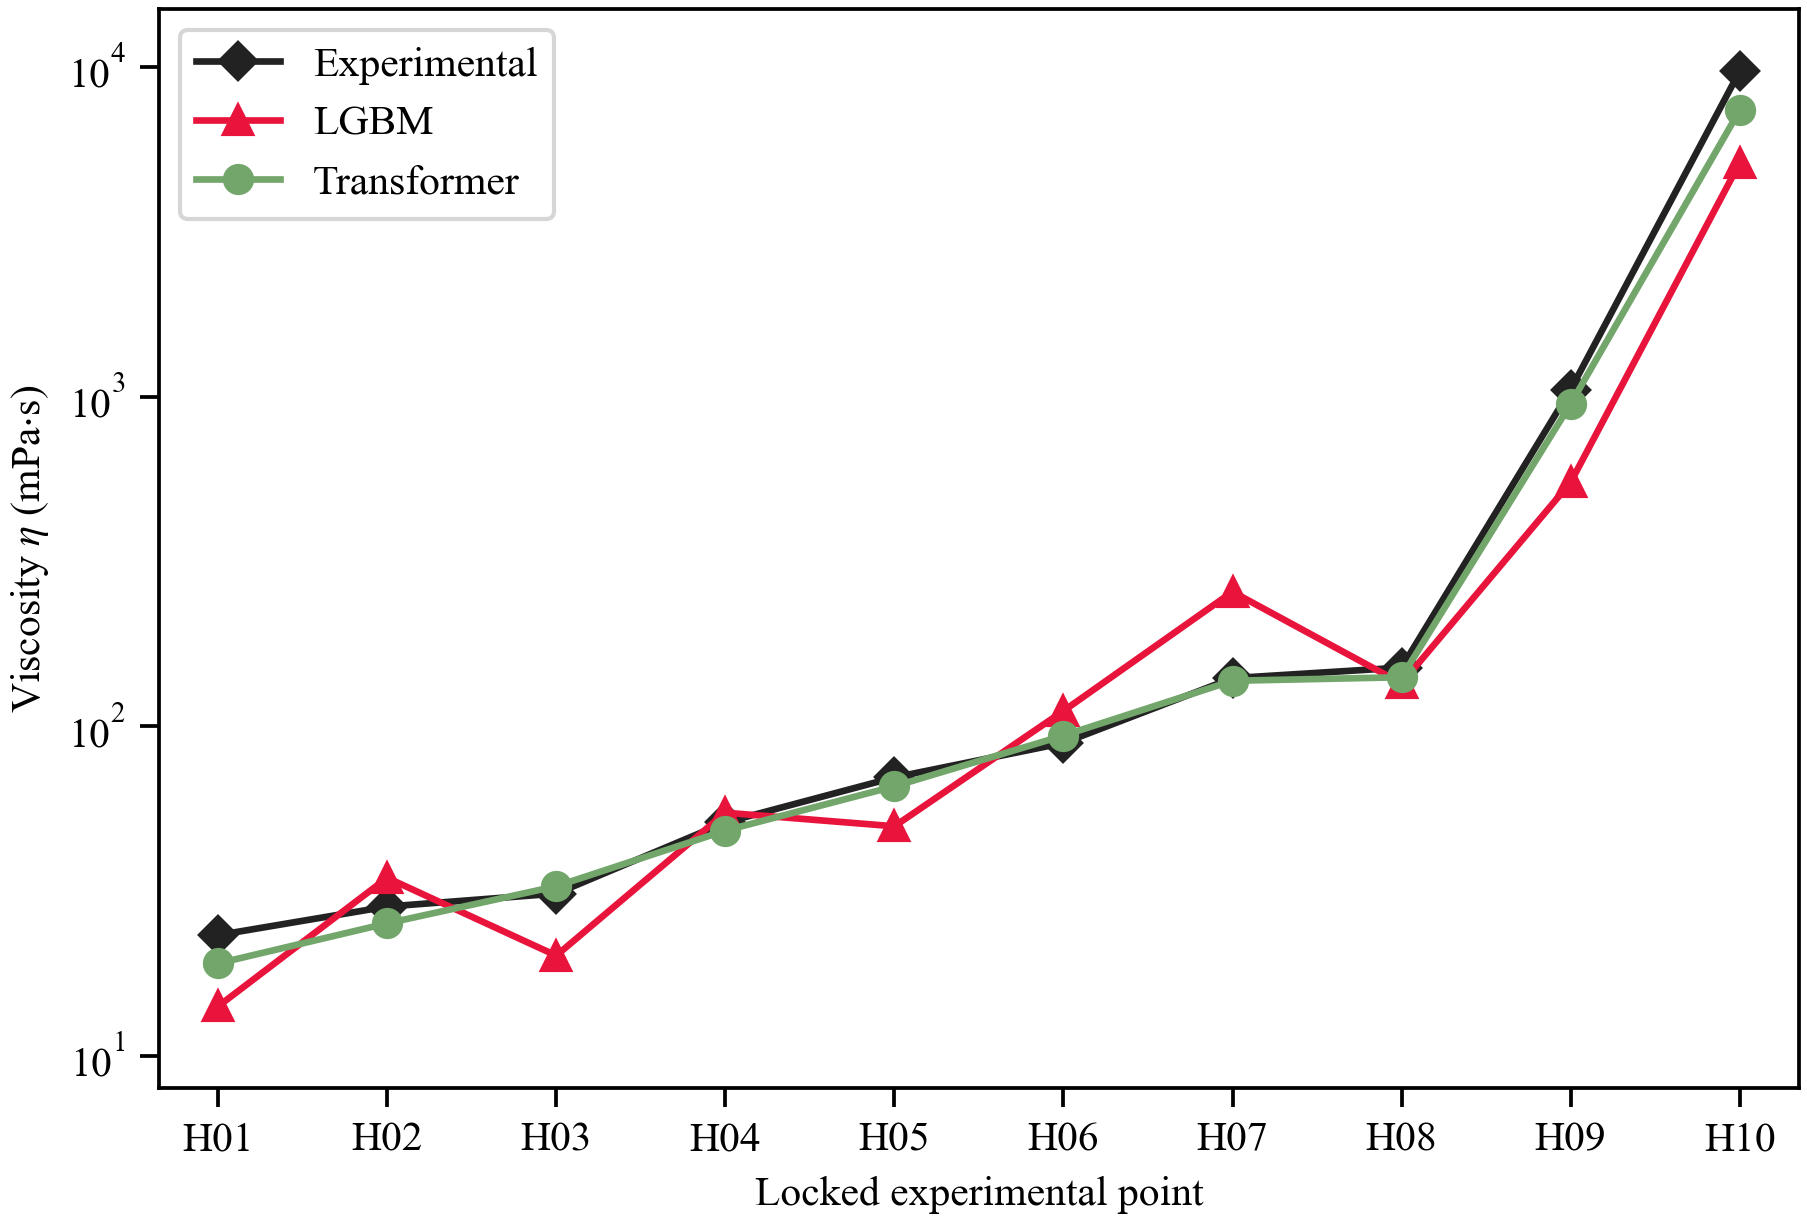

图片名称： 锁定10点LGBM与Transformer实验黏度和预测黏度对比图
PNG： D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\figures\PNG\锁定10点LGBM与Transformer实验黏度和预测黏度对比图.png
SVG： D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\figures\SVG\锁定10点LGBM与Transformer实验黏度和预测黏度对比图.svg
PDF： D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\figures\PDF\锁定10点LGBM与Transformer实验黏度和预测黏度对比图.pdf
CSV： D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\figures\CSV\锁定10点LGBM与Transformer实验黏度和预测黏度对比图.csv
Cell 6 锁定10点实验黏度与两模型预测黏度折线对比图生成完成 ✓
experimental style              = black diamond line
LGBM style                      = red triangle line
Transformer style               = green circle line
legend position                 = upper left
displa

,holdout_id,Experimental_eta_mPa_s,LGBM_pred_eta_mPa_s,Transformer_pred_eta_mPa_s
0,H01,23.27,14.151252,19.098444
1,H02,28.40,34.716042,25.263220
2,H03,31.10,20.167380,32.729558
3,H04,51.10,54.702712,48.282485
4,H05,70.00,49.750709,65.760073
5,H06,89.00,111.344683,93.742614
6,H07,140.00,255.842151,137.436490
7,H08,150.70,134.963953,140.848728
8,H09,1050.00,549.495635,949.608918
9,H10,9700.00,5115.204723,7385.101461


In [14]:
# Cell 6 | 绘制锁定10点实验黏度与两模型预测黏度折线对比图

from matplotlib.ticker import (
    FixedLocator,
    LogFormatterMathtext,
    NullFormatter,
    NullLocator,
)

# Cell 6重新运行时，从本轮4张图片的第一张重新登记。
FIGURE_RECORDS = []

# 固定本图配色和样式。
EXPERIMENTAL_COLOR = "#222222"
LGBM_COLOR = "#E9143C"
TRANSFORMER_COLOR = "#72A66A"


def save_figure_bundle(
    figure,
    figure_data,
    file_stem,
    figure_category,
):
    png_path = (
        PNG_DIR
        / f"{file_stem}.png"
    )

    svg_path = (
        SVG_DIR
        / f"{file_stem}.svg"
    )

    pdf_path = (
        PDF_DIR
        / f"{file_stem}.pdf"
    )

    csv_path = (
        CSV_DIR
        / f"{file_stem}.csv"
    )

    # 直接覆盖此前同名文件。
    figure.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.03,
    )

    figure.savefig(
        svg_path,
        bbox_inches="tight",
        pad_inches=0.03,
    )

    figure.savefig(
        pdf_path,
        bbox_inches="tight",
        pad_inches=0.03,
    )

    save_csv_atomic(
        figure_data,
        csv_path,
    )

    record = {
        "File_stem": file_stem,
        "Figure_category": (
            figure_category
        ),
        "PNG_path": str(
            png_path
        ),
        "SVG_path": str(
            svg_path
        ),
        "PDF_path": str(
            pdf_path
        ),
        "CSV_path": str(
            csv_path
        ),
        "PNG_sha256": (
            calculate_sha256(
                png_path
            )
        ),
        "SVG_sha256": (
            calculate_sha256(
                svg_path
            )
        ),
        "PDF_sha256": (
            calculate_sha256(
                pdf_path
            )
        ),
        "CSV_sha256": (
            calculate_sha256(
                csv_path
            )
        ),
        "Grid_lines_visible": False,
        "Title_embedded_in_figure": False,
        "Displayed_in_notebook": True,
    }

    FIGURE_RECORDS.append(
        record
    )

    plt.close(
        figure
    )

    display(
        Image(
            filename=str(
                png_path
            )
        )
    )

    print(
        "图片名称：",
        file_stem,
    )

    print(
        "PNG：",
        png_path,
    )

    print(
        "SVG：",
        svg_path,
    )

    print(
        "PDF：",
        pdf_path,
    )

    print(
        "CSV：",
        csv_path,
    )

    return record


required_plot_columns = [
    "holdout_id",
    "Experimental_eta_mPa_s",
    "LGBM_pred_eta_mPa_s",
    "Transformer_pred_eta_mPa_s",
]

missing_plot_columns = [
    column
    for column in required_plot_columns
    if column
    not in external_detail_wide.columns
]

if missing_plot_columns:
    raise KeyError(
        "锁定10点结果宽表缺少作图字段："
        f"{missing_plot_columns}\n"
        "当前字段为："
        f"{list(external_detail_wide.columns)}"
    )

plot_data_1 = (
    external_detail_wide[
        required_plot_columns
    ]
    .copy()
)

# 明确固定H01—H10顺序。
plot_data_1[
    "_holdout_number"
] = (
    plot_data_1[
        "holdout_id"
    ]
    .astype(str)
    .str.extract(
        r"(\d+)",
        expand=False,
    )
    .astype(int)
)

plot_data_1 = (
    plot_data_1
    .sort_values(
        "_holdout_number"
    )
    .drop(
        columns=[
            "_holdout_number"
        ]
    )
    .reset_index(
        drop=True
    )
)

for column in [
    "Experimental_eta_mPa_s",
    "LGBM_pred_eta_mPa_s",
    "Transformer_pred_eta_mPa_s",
]:
    plot_data_1[
        column
    ] = pd.to_numeric(
        plot_data_1[
            column
        ],
        errors="raise",
    )

    if (
        plot_data_1[
            column
        ]
        <= 0
    ).any():
        raise RuntimeError(
            f"{column}中存在非正值，"
            "不能使用对数纵坐标。"
        )

x = np.arange(
    len(
        plot_data_1
    )
)

figure_1, axis_1 = plt.subplots(
    figsize=(
        16 / 2.54,
        11 / 2.54,
    )
)

# 实验值：黑色菱形折线。
axis_1.plot(
    x,
    plot_data_1[
        "Experimental_eta_mPa_s"
    ],
    color=EXPERIMENTAL_COLOR,
    linewidth=1.6,
    marker="D",
    markersize=6.0,
    markerfacecolor=(
        EXPERIMENTAL_COLOR
    ),
    markeredgecolor=(
        EXPERIMENTAL_COLOR
    ),
    label="Experimental",
    zorder=3,
)

# LGBM：红色三角形折线。
axis_1.plot(
    x,
    plot_data_1[
        "LGBM_pred_eta_mPa_s"
    ],
    color=LGBM_COLOR,
    linewidth=1.6,
    marker="^",
    markersize=6.5,
    markerfacecolor=(
        LGBM_COLOR
    ),
    markeredgecolor=(
        LGBM_COLOR
    ),
    label="LGBM",
    zorder=3,
)

# Transformer：绿色圆形折线。
axis_1.plot(
    x,
    plot_data_1[
        "Transformer_pred_eta_mPa_s"
    ],
    color=TRANSFORMER_COLOR,
    linewidth=1.6,
    marker="o",
    markersize=6.5,
    markerfacecolor=(
        TRANSFORMER_COLOR
    ),
    markeredgecolor=(
        TRANSFORMER_COLOR
    ),
    label="Transformer",
    zorder=3,
)

axis_1.set_yscale(
    "log"
)

axis_1.set_xticks(
    x
)

axis_1.set_xticklabels(
    plot_data_1[
        "holdout_id"
    ]
)

axis_1.set_xlabel(
    "Locked experimental point"
)

axis_1.set_ylabel(
    r"Viscosity $\eta$ "
    r"(mPa$\cdot$s)"
)

# 纵坐标只显示10¹、10²、10³和10⁴四个主刻度。
major_y_ticks = [
    1e1,
    1e2,
    1e3,
    1e4,
]

axis_1.yaxis.set_major_locator(
    FixedLocator(
        major_y_ticks
    )
)

axis_1.yaxis.set_major_formatter(
    LogFormatterMathtext(
        base=10
    )
)

# 不显示次刻度及次刻度标签。
axis_1.yaxis.set_minor_locator(
    NullLocator()
)

axis_1.yaxis.set_minor_formatter(
    NullFormatter()
)

all_eta_values = np.concatenate(
    [
        plot_data_1[
            "Experimental_eta_mPa_s"
        ].to_numpy(
            dtype=float
        ),
        plot_data_1[
            "LGBM_pred_eta_mPa_s"
        ].to_numpy(
            dtype=float
        ),
        plot_data_1[
            "Transformer_pred_eta_mPa_s"
        ].to_numpy(
            dtype=float
        ),
    ]
)

# 保留10¹和10⁴刻度，并给图例留出空间。
y_lower = min(
    8.0,
    float(
        np.min(
            all_eta_values
        )
    )
    / 1.15,
)

y_upper = max(
    1.50e4,
    float(
        np.max(
            all_eta_values
        )
    )
    * 1.45,
)

axis_1.set_ylim(
    y_lower,
    y_upper,
)

axis_1.set_xlim(
    -0.35,
    len(x) - 0.65,
)

# 图例放在图内左上角，避免遮挡H09—H10附近的折线。
axis_1.legend(
    loc="upper left",
    frameon=True,
)

axis_1.grid(
    False
)

axis_1.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=4.5,
    width=0.9,
)

for spine in axis_1.spines.values():
    spine.set_linewidth(
        0.9
    )

# 不在图片内部嵌入图题。
figure_1.tight_layout()

FIGURE_1_STEM = (
    "锁定10点LGBM与Transformer"
    "实验黏度和预测黏度对比图"
)

save_figure_bundle(
    figure=figure_1,
    figure_data=plot_data_1,
    file_stem=FIGURE_1_STEM,
    figure_category=(
        "experimental_vs_predicted_eta"
    ),
)

print("=" * 108)

print(
    "Cell 6 锁定10点实验黏度与"
    "两模型预测黏度折线对比图生成完成 ✓"
)

print("=" * 108)

print(
    "experimental style              =",
    "black diamond line",
)

print(
    "LGBM style                      =",
    "red triangle line",
)

print(
    "Transformer style               =",
    "green circle line",
)

print(
    "legend position                 =",
    "upper left",
)

print(
    "displayed y major ticks         =",
    major_y_ticks,
)

print(
    "y minor ticks displayed         =",
    False,
)

print(
    "grid lines visible              =",
    False,
)

print(
    "embedded figure title           =",
    False,
)

print(
    "figure name changed             =",
    False,
)

print(
    "figure output paths changed     =",
    False,
)

print(
    "figure records registered       =",
    len(
        FIGURE_RECORDS
    ),
)

display(
    plot_data_1
)

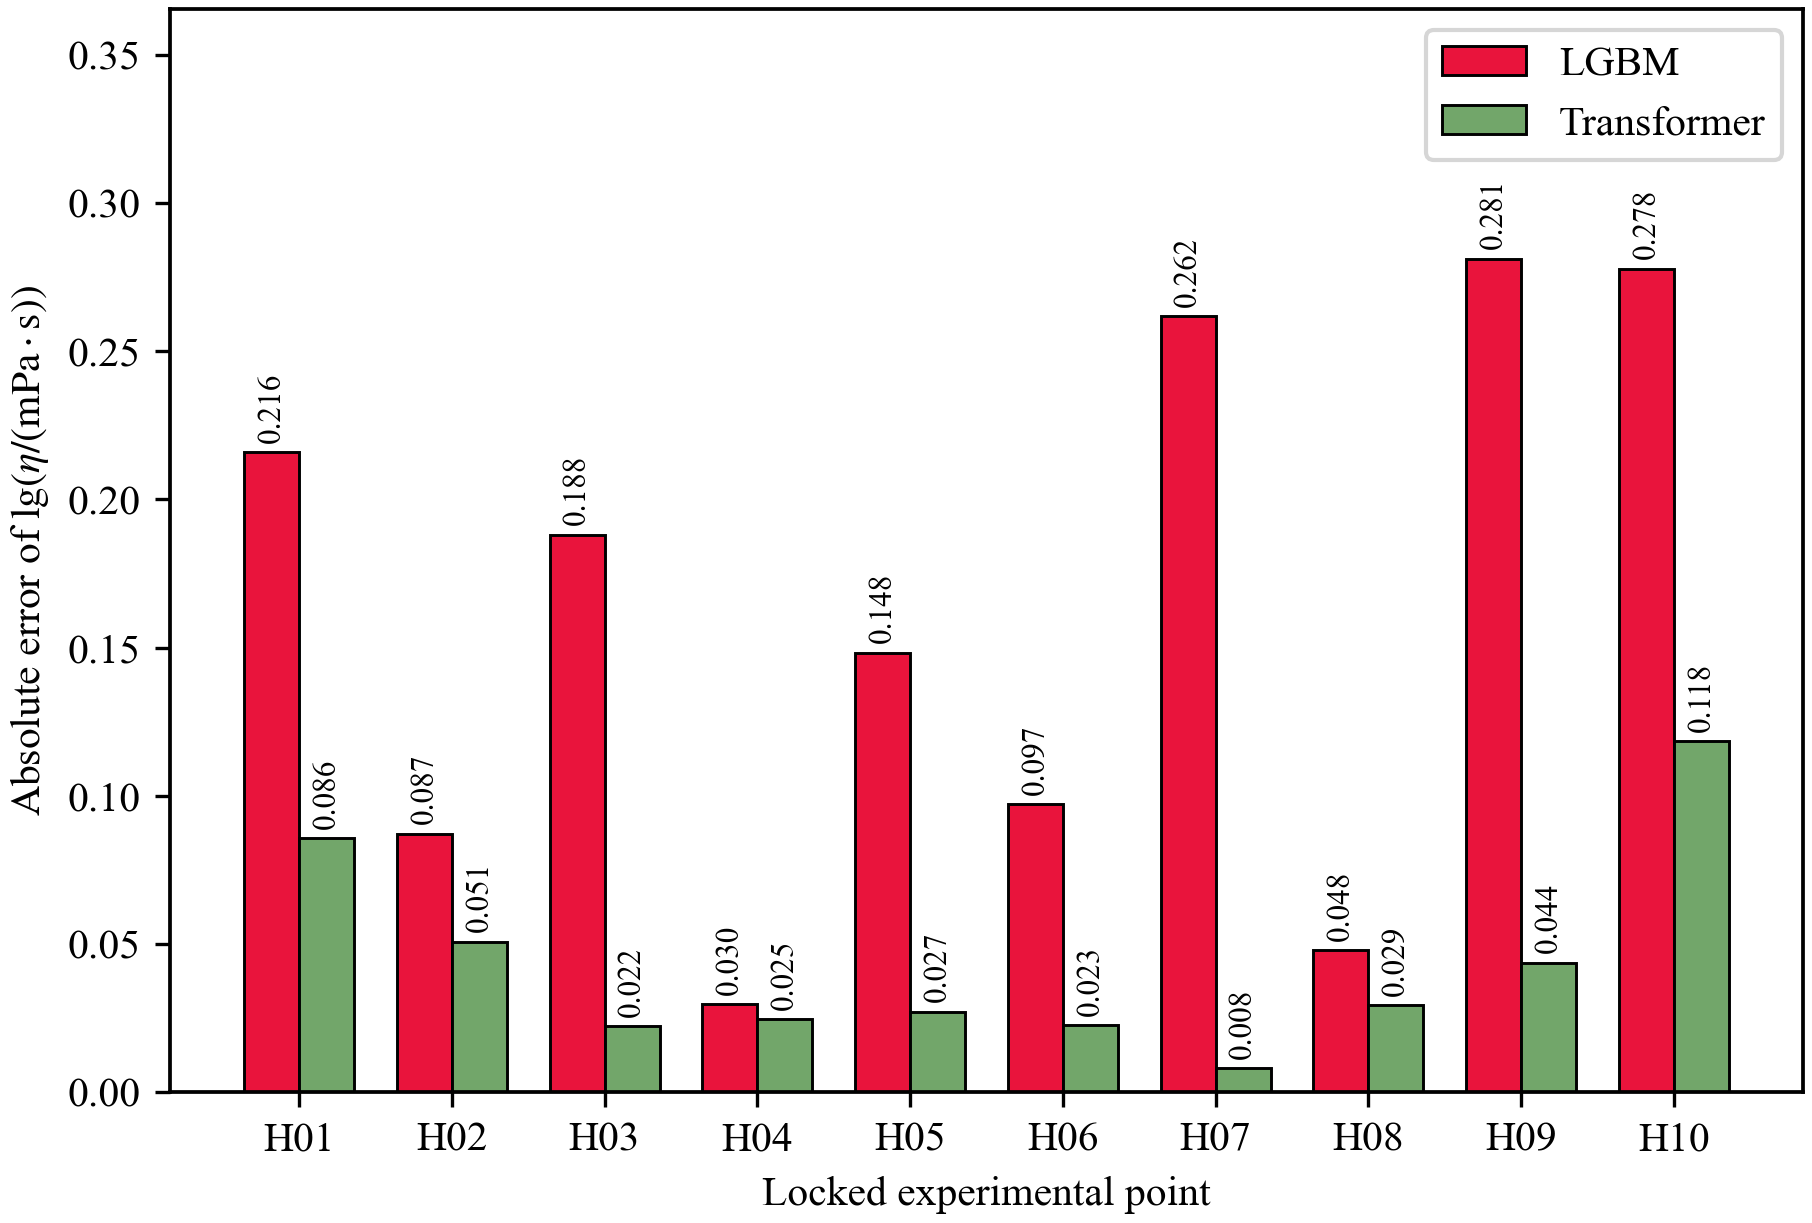

图片名称： 锁定10点LGBM与Transformer逐点绝对误差对比图
PNG： D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\figures\PNG\锁定10点LGBM与Transformer逐点绝对误差对比图.png
SVG： D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\figures\SVG\锁定10点LGBM与Transformer逐点绝对误差对比图.svg
PDF： D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\figures\PDF\锁定10点LGBM与Transformer逐点绝对误差对比图.pdf
CSV： D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\figures\CSV\锁定10点LGBM与Transformer逐点绝对误差对比图.csv


{'File_stem': '锁定10点LGBM与Transformer逐点绝对误差对比图',
 'Figure_category': 'pointwise_absolute_error',
 'PNG_path': 'D:\\jupyter\\IL_ML_Project\\small_paper_data\\viscosity_10point_holdout\\outputs\\external_holdout_10point_LGBM_Transformer_final\\figures\\PNG\\锁定10点LGBM与Transformer逐点绝对误差对比图.png',
 'SVG_path': 'D:\\jupyter\\IL_ML_Project\\small_paper_data\\viscosity_10point_holdout\\outputs\\external_holdout_10point_LGBM_Transformer_final\\figures\\SVG\\锁定10点LGBM与Transformer逐点绝对误差对比图.svg',
 'PDF_path': 'D:\\jupyter\\IL_ML_Project\\small_paper_data\\viscosity_10point_holdout\\outputs\\external_holdout_10point_LGBM_Transformer_final\\figures\\PDF\\锁定10点LGBM与Transformer逐点绝对误差对比图.pdf',
 'CSV_path': 'D:\\jupyter\\IL_ML_Project\\small_paper_data\\viscosity_10point_holdout\\outputs\\external_holdout_10point_LGBM_Transformer_final\\figures\\CSV\\锁定10点LGBM与Transformer逐点绝对误差对比图.csv',
 'PNG_sha256': '5752b1767d80b41589451d660d1fe8ea5ae9a720823bf13e0395c63563ff524a',
 'SVG_sha256': '141b6b620724f99233692

In [15]:
# Cell 7 | 绘制锁定10点LGBM与Transformer逐点绝对误差对比图

plot_data_2 = (
    external_detail_wide[
        [
            "holdout_id",
            "LGBM_absolute_error_lg_eta",
            "Transformer_absolute_error_lg_eta",
        ]
    ]
    .copy()
)

x = np.arange(
    len(plot_data_2)
)

bar_width = 0.36

figure_2, axis_2 = plt.subplots(
    figsize=(
        16 / 2.54,
        11 / 2.54,
    )
)

lgbm_bars = axis_2.bar(
    x - bar_width / 2,
    plot_data_2[
        "LGBM_absolute_error_lg_eta"
    ],
    width=bar_width,
    color=LGBM_COLOR,
    edgecolor="black",
    linewidth=0.7,
    label="LGBM",
)

transformer_bars = axis_2.bar(
    x + bar_width / 2,
    plot_data_2[
        "Transformer_absolute_error_lg_eta"
    ],
    width=bar_width,
    color=TRANSFORMER_COLOR,
    edgecolor="black",
    linewidth=0.7,
    label="Transformer",
)

axis_2.bar_label(
    lgbm_bars,
    fmt="%.3f",
    padding=2.3,
    fontsize=7.5,
    rotation=90,
)

axis_2.bar_label(
    transformer_bars,
    fmt="%.3f",
    padding=2.3,
    fontsize=7.5,
    rotation=90,
)

axis_2.set_xticks(
    x
)

axis_2.set_xticklabels(
    plot_data_2[
        "holdout_id"
    ]
)

axis_2.set_xlabel(
    "Locked experimental point"
)

axis_2.set_ylabel(
    r"Absolute error of "
    r"$\lg(\eta/(\mathrm{mPa\cdot s}))$"
)

maximum_error = float(
    plot_data_2[
        [
            "LGBM_absolute_error_lg_eta",
            "Transformer_absolute_error_lg_eta",
        ]
    ]
    .to_numpy(
        dtype=float
    )
    .max()
)

axis_2.set_ylim(
    0,
    maximum_error * 1.30,
)

axis_2.legend(
    loc="upper right",
    frameon=True,
)

axis_2.grid(False)

for spine in axis_2.spines.values():
    spine.set_linewidth(0.9)

figure_2.tight_layout()

FIGURE_2_STEM = (
    "锁定10点LGBM与Transformer"
    "逐点绝对误差对比图"
)

save_figure_bundle(
    figure=figure_2,
    figure_data=plot_data_2,
    file_stem=FIGURE_2_STEM,
    figure_category=(
        "pointwise_absolute_error"
    ),
)

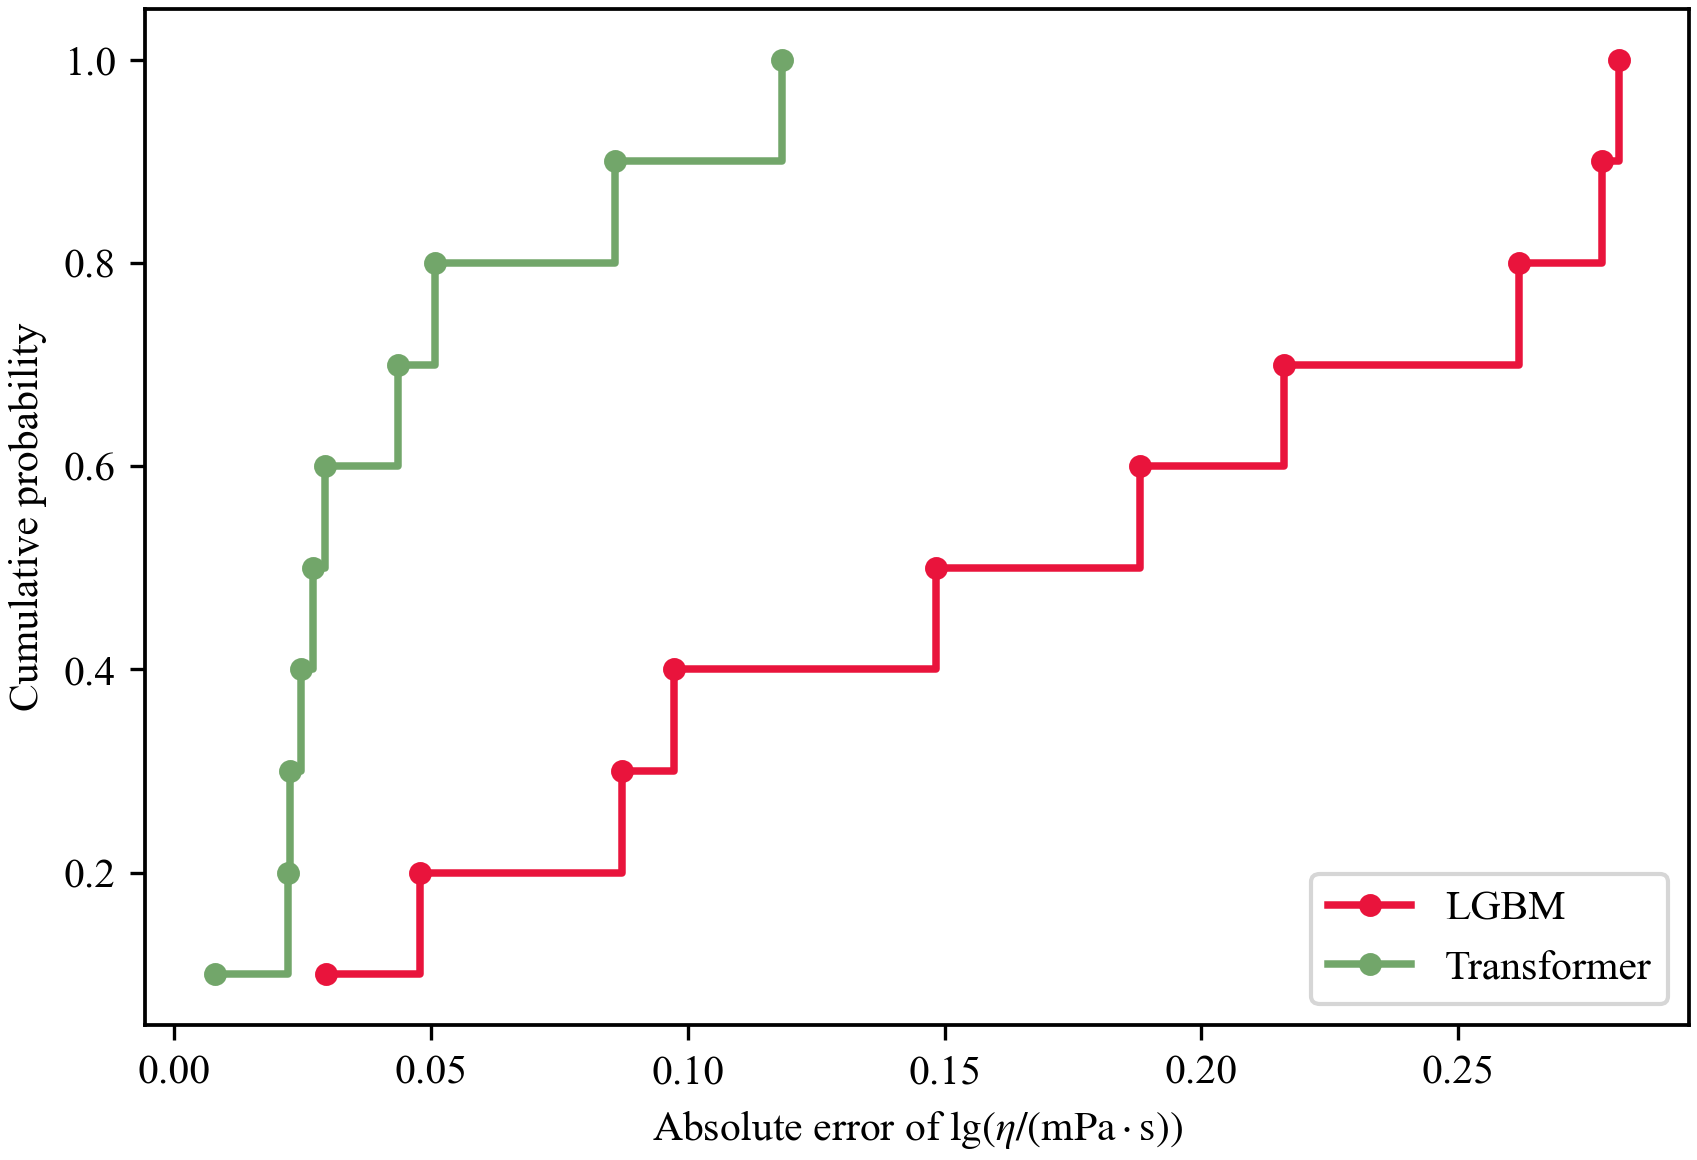

图片名称： 锁定10点LGBM与Transformer绝对误差累积分布图
PNG： D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\figures\PNG\锁定10点LGBM与Transformer绝对误差累积分布图.png
SVG： D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\figures\SVG\锁定10点LGBM与Transformer绝对误差累积分布图.svg
PDF： D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\figures\PDF\锁定10点LGBM与Transformer绝对误差累积分布图.pdf
CSV： D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\figures\CSV\锁定10点LGBM与Transformer绝对误差累积分布图.csv


{'File_stem': '锁定10点LGBM与Transformer绝对误差累积分布图',
 'Figure_category': 'absolute_error_ecdf',
 'PNG_path': 'D:\\jupyter\\IL_ML_Project\\small_paper_data\\viscosity_10point_holdout\\outputs\\external_holdout_10point_LGBM_Transformer_final\\figures\\PNG\\锁定10点LGBM与Transformer绝对误差累积分布图.png',
 'SVG_path': 'D:\\jupyter\\IL_ML_Project\\small_paper_data\\viscosity_10point_holdout\\outputs\\external_holdout_10point_LGBM_Transformer_final\\figures\\SVG\\锁定10点LGBM与Transformer绝对误差累积分布图.svg',
 'PDF_path': 'D:\\jupyter\\IL_ML_Project\\small_paper_data\\viscosity_10point_holdout\\outputs\\external_holdout_10point_LGBM_Transformer_final\\figures\\PDF\\锁定10点LGBM与Transformer绝对误差累积分布图.pdf',
 'CSV_path': 'D:\\jupyter\\IL_ML_Project\\small_paper_data\\viscosity_10point_holdout\\outputs\\external_holdout_10point_LGBM_Transformer_final\\figures\\CSV\\锁定10点LGBM与Transformer绝对误差累积分布图.csv',
 'PNG_sha256': '8b112fc2fcb86cb73a45d649818796bbd2c6fc399930bc783bda678da47b1ab6',
 'SVG_sha256': '308567748abea4bfd3c975da9f

In [16]:
# Cell 8 | 绘制锁定10点两模型绝对误差累积分布图

ecdf_records = []

figure_3, axis_3 = plt.subplots(
    figsize=(
        15 / 2.54,
        10.5 / 2.54,
    )
)

for (
    model_label,
    error_column,
    color,
) in [
    (
        "LGBM",
        "LGBM_absolute_error_lg_eta",
        LGBM_COLOR,
    ),
    (
        "Transformer",
        "Transformer_absolute_error_lg_eta",
        TRANSFORMER_COLOR,
    ),
]:
    sorted_error = np.sort(
        external_detail_wide[
            error_column
        ].to_numpy(
            dtype=float
        )
    )

    cumulative_probability = (
        np.arange(
            1,
            len(sorted_error) + 1,
        )
        /
        len(sorted_error)
    )

    axis_3.step(
        sorted_error,
        cumulative_probability,
        where="post",
        color=color,
        linewidth=1.8,
        marker="o",
        markersize=4.5,
        label=model_label,
    )

    for error_value, probability in zip(
        sorted_error,
        cumulative_probability,
    ):
        ecdf_records.append(
            {
                "Model": model_label,
                "Absolute_error_lg_eta": (
                    error_value
                ),
                "Cumulative_probability": (
                    probability
                ),
            }
        )

plot_data_3 = pd.DataFrame(
    ecdf_records
)

axis_3.set_xlabel(
    r"Absolute error of "
    r"$\lg(\eta/(\mathrm{mPa\cdot s}))$"
)

axis_3.set_ylabel(
    "Cumulative probability"
)

axis_3.set_ylim(
    0.05,
    1.05,
)

axis_3.legend(
    loc="lower right",
    frameon=True,
)

axis_3.grid(False)

for spine in axis_3.spines.values():
    spine.set_linewidth(0.9)

figure_3.tight_layout()

FIGURE_3_STEM = (
    "锁定10点LGBM与Transformer"
    "绝对误差累积分布图"
)

save_figure_bundle(
    figure=figure_3,
    figure_data=plot_data_3,
    file_stem=FIGURE_3_STEM,
    figure_category=(
        "absolute_error_ecdf"
    ),
)

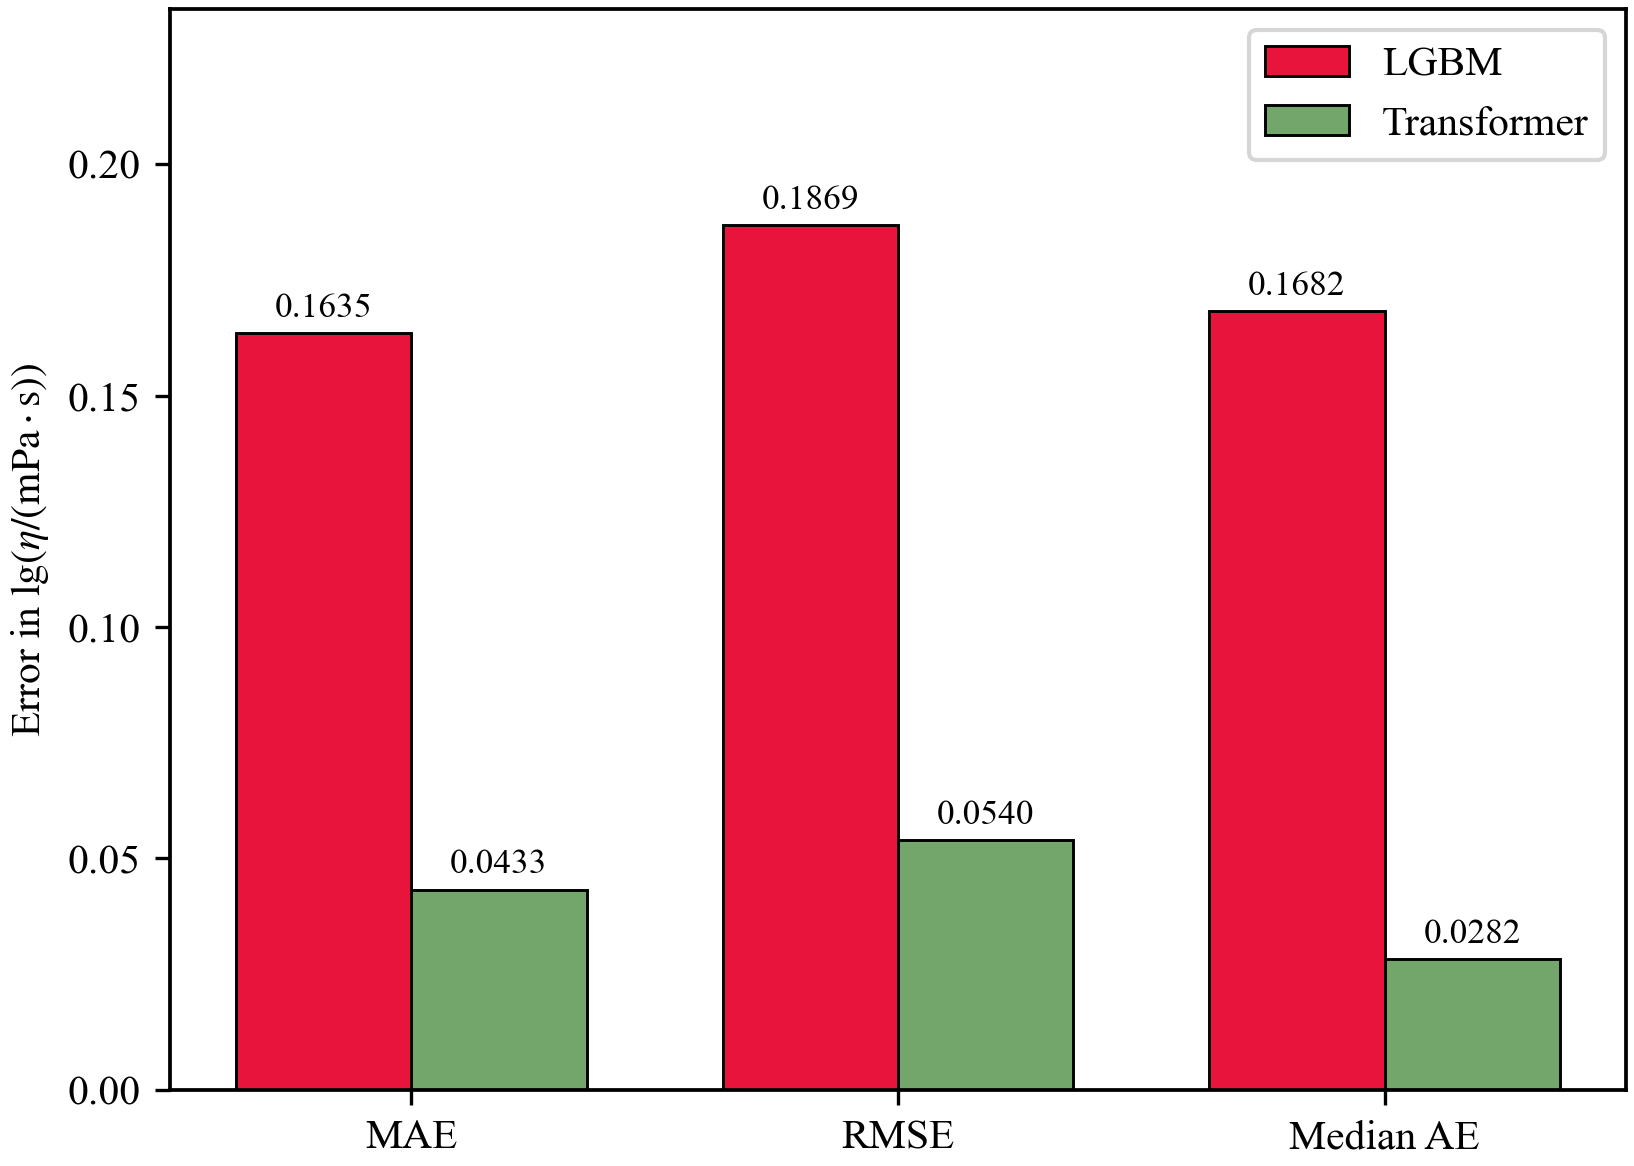

图片名称： 锁定10点LGBM与Transformer核心误差指标对比图
PNG： D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\figures\PNG\锁定10点LGBM与Transformer核心误差指标对比图.png
SVG： D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\figures\SVG\锁定10点LGBM与Transformer核心误差指标对比图.svg
PDF： D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\figures\PDF\锁定10点LGBM与Transformer核心误差指标对比图.pdf
CSV： D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\figures\CSV\锁定10点LGBM与Transformer核心误差指标对比图.csv


{'File_stem': '锁定10点LGBM与Transformer核心误差指标对比图',
 'Figure_category': 'core_error_metrics',
 'PNG_path': 'D:\\jupyter\\IL_ML_Project\\small_paper_data\\viscosity_10point_holdout\\outputs\\external_holdout_10point_LGBM_Transformer_final\\figures\\PNG\\锁定10点LGBM与Transformer核心误差指标对比图.png',
 'SVG_path': 'D:\\jupyter\\IL_ML_Project\\small_paper_data\\viscosity_10point_holdout\\outputs\\external_holdout_10point_LGBM_Transformer_final\\figures\\SVG\\锁定10点LGBM与Transformer核心误差指标对比图.svg',
 'PDF_path': 'D:\\jupyter\\IL_ML_Project\\small_paper_data\\viscosity_10point_holdout\\outputs\\external_holdout_10point_LGBM_Transformer_final\\figures\\PDF\\锁定10点LGBM与Transformer核心误差指标对比图.pdf',
 'CSV_path': 'D:\\jupyter\\IL_ML_Project\\small_paper_data\\viscosity_10point_holdout\\outputs\\external_holdout_10point_LGBM_Transformer_final\\figures\\CSV\\锁定10点LGBM与Transformer核心误差指标对比图.csv',
 'PNG_sha256': '839560be574373cbf84d24ed97b65921e25e46ad9308faca5d773773faaeede5',
 'SVG_sha256': 'e47442b681dc7363037c62dfb23

In [17]:
# Cell 9 | 绘制锁定10点两模型核心误差指标对比图

metric_order = [
    "MAE_lg_eta",
    "RMSE_lg_eta",
    "Median_AE_lg_eta",
]

metric_labels = [
    r"MAE",
    r"RMSE",
    r"Median AE",
]

lgbm_metric_row = (
    external_summary_metrics
    .loc[
        external_summary_metrics[
            "Model"
        ]
        == "LightGBM"
    ]
    .iloc[0]
)

transformer_metric_row = (
    external_summary_metrics
    .loc[
        external_summary_metrics[
            "Model"
        ]
        == "Transformer"
    ]
    .iloc[0]
)

plot_data_4 = pd.DataFrame(
    {
        "Metric": metric_labels,
        "LGBM": [
            float(
                lgbm_metric_row[
                    metric
                ]
            )
            for metric in metric_order
        ],
        "Transformer": [
            float(
                transformer_metric_row[
                    metric
                ]
            )
            for metric in metric_order
        ],
    }
)

x = np.arange(
    len(metric_labels)
)

bar_width = 0.36

figure_4, axis_4 = plt.subplots(
    figsize=(
        14.5 / 2.54,
        10.5 / 2.54,
    )
)

lgbm_metric_bars = axis_4.bar(
    x - bar_width / 2,
    plot_data_4["LGBM"],
    width=bar_width,
    color=LGBM_COLOR,
    edgecolor="black",
    linewidth=0.7,
    label="LGBM",
)

transformer_metric_bars = axis_4.bar(
    x + bar_width / 2,
    plot_data_4["Transformer"],
    width=bar_width,
    color=TRANSFORMER_COLOR,
    edgecolor="black",
    linewidth=0.7,
    label="Transformer",
)

axis_4.bar_label(
    lgbm_metric_bars,
    fmt="%.4f",
    padding=2.3,
    fontsize=8.5,
)

axis_4.bar_label(
    transformer_metric_bars,
    fmt="%.4f",
    padding=2.3,
    fontsize=8.5,
)

axis_4.set_xticks(
    x
)

axis_4.set_xticklabels(
    metric_labels
)

axis_4.set_ylabel(
    r"Error in "
    r"$\lg(\eta/(\mathrm{mPa\cdot s}))$"
)

metric_maximum = float(
    plot_data_4[
        [
            "LGBM",
            "Transformer",
        ]
    ]
    .to_numpy(
        dtype=float
    )
    .max()
)

axis_4.set_ylim(
    0,
    metric_maximum * 1.25,
)

axis_4.legend(
    loc="upper right",
    frameon=True,
)

axis_4.grid(False)

for spine in axis_4.spines.values():
    spine.set_linewidth(0.9)

figure_4.tight_layout()

FIGURE_4_STEM = (
    "锁定10点LGBM与Transformer"
    "核心误差指标对比图"
)

save_figure_bundle(
    figure=figure_4,
    figure_data=plot_data_4,
    file_stem=FIGURE_4_STEM,
    figure_category=(
        "core_error_metrics"
    ),
)

In [18]:
# Cell 10 | 完成锁定10点两模型补充验证最终完整性审计

if (
    "FIGURE_RECORDS"
    not in globals()
):
    raise RuntimeError(
        "未找到FIGURE_RECORDS，"
        "请确认Cell 6—Cell 9均已在当前Kernel中运行。"
    )

if len(FIGURE_RECORDS) != 4:
    raise RuntimeError(
        f"图形记录数为{len(FIGURE_RECORDS)}，"
        "预期为4。"
    )

figure_audit_df = pd.DataFrame(
    FIGURE_RECORDS
)

for _, row in figure_audit_df.iterrows():
    for format_name in [
        "PNG",
        "SVG",
        "PDF",
        "CSV",
    ]:
        path = Path(
            row[
                f"{format_name}_path"
            ]
        )

        if not path.exists():
            raise FileNotFoundError(
                f"缺少图形输出：{path}"
            )

        current_hash = calculate_sha256(
            path
        )

        if (
            current_hash
            != row[
                f"{format_name}_sha256"
            ]
        ):
            raise RuntimeError(
                f"图形输出哈希发生变化：{path}"
            )

FIGURE_AUDIT_PATH = (
    LOG_DIR
    / "locked10_figure_generation_audit.csv"
)

save_csv_atomic(
    figure_audit_df,
    FIGURE_AUDIT_PATH,
)

required_outputs = [
    HOLDOUT_INPUT_PATH,
    HOLDOUT_IDENTITY_AUDIT_PATH,
    HOLDOUT_INPUT_MANIFEST_PATH,
    LOCKED10_FEATURE_PATH,
    LOCKED10_FEATURE_AUDIT_PATH,
    LOCKED10_FEATURE_MANIFEST_PATH,
    UNLABELED_PREDICTION_PATH,
    PREDICTION_FREEZE_MANIFEST_PATH,
    EXTERNAL_SUMMARY_PATH,
    EXTERNAL_DETAIL_WIDE_PATH,
    EXTERNAL_DETAIL_LONG_PATH,
    LABEL_READ_AUDIT_PATH,
    PAPER_LGBM_SUMMARY_PATH,
    PAPER_LGBM_DETAIL_PATH,
    SUPPLEMENTARY_SUMMARY_PATH,
    SUPPLEMENTARY_DETAIL_PATH,
    FIGURE_AUDIT_PATH,
]

output_check_records = []

for path in required_outputs:
    path = Path(path)

    output_check_records.append(
        {
            "File_name": path.name,
            "Path": str(path),
            "Exists": path.exists(),
            "Size_bytes": (
                int(
                    path.stat().st_size
                )
                if path.exists()
                else 0
            ),
            "SHA256": (
                calculate_sha256(path)
                if path.exists()
                else None
            ),
        }
    )

for _, figure_row in (
    figure_audit_df.iterrows()
):
    for format_name in [
        "PNG",
        "SVG",
        "PDF",
        "CSV",
    ]:
        figure_path = Path(
            figure_row[
                f"{format_name}_path"
            ]
        )

        output_check_records.append(
            {
                "File_name": (
                    figure_path.name
                ),
                "Path": str(
                    figure_path
                ),
                "Exists": (
                    figure_path.exists()
                ),
                "Size_bytes": int(
                    figure_path
                    .stat()
                    .st_size
                ),
                "SHA256": (
                    calculate_sha256(
                        figure_path
                    )
                ),
            }
        )

output_check_df = pd.DataFrame(
    output_check_records
)

if not output_check_df[
    "Exists"
].all():
    display(
        output_check_df.loc[
            ~output_check_df[
                "Exists"
            ]
        ]
    )

    raise RuntimeError(
        "锁定10点补充验证仍有必要输出缺失。"
    )

OUTPUT_CHECK_PATH = (
    LOG_DIR
    / "locked10_final_output_check.csv"
)

FINAL_VALIDATION_MANIFEST_PATH = (
    LOG_DIR
    / "locked10_LGBM_Transformer_validation_manifest.json"
)

save_csv_atomic(
    output_check_df,
    OUTPUT_CHECK_PATH,
)

final_validation_manifest = {
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "run_code_version": RUN_CODE_VERSION,
    "status": (
        "locked10_LGBM_Transformer_"
        "supplementary_validation_completed"
    ),
    "task": (
        "locked_10point_seen_IL_new_condition_"
        "supplementary_validation"
    ),
    "property": "viscosity",
    "target": "lg_eta",
    "representation": "MPNN",
    "fingerprints_used": False,
    "external_rows": (
        EXPECTED_EXTERNAL_ROWS
    ),
    "validation_scope": {
        "all_10_ILs_seen_in_development_data": True,
        "exact_IL_T_P_overlap_with_"
        "development_data": 0,
        "interpretation": (
            "supplementary_condition_point_"
            "validation_not_unseen_IL_validation"
        ),
    },
    "model_roles": {
        "LightGBM": (
            "final_application_model"
        ),
        "Transformer": (
            "supplementary_control_model"
        ),
        "virtual_IL_prediction_model": (
            "LightGBM"
        ),
    },
    "model_lock": {
        "final_model_selected_before_"
        "external_label_read": True,
        "external10_used_for_model_reselection": False,
        "external10_may_change_final_model": False,
        "Transformer_used_for_virtual_IL_"
        "prediction": False,
    },
    "prediction_freeze": {
        "predictions_generated_before_"
        "label_read": True,
        "prediction_manifest": str(
            PREDICTION_FREEZE_MANIFEST_PATH
        ),
        "prediction_manifest_sha256": (
            calculate_sha256(
                PREDICTION_FREEZE_MANIFEST_PATH
            )
        ),
        "unlabeled_prediction_file": str(
            UNLABELED_PREDICTION_PATH
        ),
        "unlabeled_prediction_file_sha256": (
            calculate_sha256(
                UNLABELED_PREDICTION_PATH
            )
        ),
    },
    "external_label_usage": {
        "used_for_training": False,
        "used_for_tuning": False,
        "used_for_scaler_fit": False,
        "used_for_model_selection": False,
        "used_for_model_reselection": False,
        "used_for_metric_calculation": True,
        "used_for_figures": True,
    },
    "models": {
        "LightGBM": {
            "path": str(
                FINAL_LGBM_PATH
            ),
            "sha256": calculate_sha256(
                FINAL_LGBM_PATH
            ),
        },
        "Transformer": {
            "path": str(
                FINAL_TRANSFORMER_PATH
            ),
            "sha256": calculate_sha256(
                FINAL_TRANSFORMER_PATH
            ),
        },
        "downstream_scaler": {
            "path": str(
                FINAL_SCALER_PATH
            ),
            "sha256": calculate_sha256(
                FINAL_SCALER_PATH
            ),
        },
    },
    "metrics": (
        external_summary_metrics
        .to_dict(
            orient="records"
        )
    ),
    "figures": {
        "unique_figures": int(
            len(figure_audit_df)
        ),
        "formats_per_figure": 4,
        "total_figure_and_data_files": int(
            len(figure_audit_df) * 4
        ),
        "all_without_grid_lines": bool(
            (
                ~figure_audit_df[
                    "Grid_lines_visible"
                ]
            ).all()
        ),
        "all_without_embedded_titles": bool(
            (
                ~figure_audit_df[
                    "Title_embedded_in_figure"
                ]
            ).all()
        ),
        "all_displayed_in_notebook": bool(
            figure_audit_df[
                "Displayed_in_notebook"
            ].all()
        ),
        "figure_records": (
            figure_audit_df
            .to_dict(
                orient="records"
            )
        ),
    },
    "verification": {
        "all_required_outputs_exist": bool(
            output_check_df[
                "Exists"
            ].all()
        ),
        "model_training_executed": False,
        "parameter_tuning_executed": False,
        "MPNN_retrained": False,
        "downstream_scaler_refitted": False,
        "old_downstream_prediction_used": False,
        "old_external_metric_used": False,
        "formal_outer_metrics_replaced": False,
        "figure_catalog_created": False,
        "table_catalog_created": False,
    },
    "outputs": {
        "summary_metrics": str(
            EXTERNAL_SUMMARY_PATH
        ),
        "wide_detail": str(
            EXTERNAL_DETAIL_WIDE_PATH
        ),
        "long_detail": str(
            EXTERNAL_DETAIL_LONG_PATH
        ),
        "paper_LGBM_summary": str(
            PAPER_LGBM_SUMMARY_PATH
        ),
        "paper_LGBM_detail": str(
            PAPER_LGBM_DETAIL_PATH
        ),
        "supplementary_summary": str(
            SUPPLEMENTARY_SUMMARY_PATH
        ),
        "supplementary_detail": str(
            SUPPLEMENTARY_DETAIL_PATH
        ),
        "figure_audit": str(
            FIGURE_AUDIT_PATH
        ),
        "output_check": str(
            OUTPUT_CHECK_PATH
        ),
        "final_manifest": str(
            FINAL_VALIDATION_MANIFEST_PATH
        ),
    },
}

save_json_atomic(
    final_validation_manifest,
    FINAL_VALIDATION_MANIFEST_PATH,
)

print("=" * 108)
print(
    "Cell 10 锁定10点两模型补充验证"
    "最终完整性审计完成 ✓"
)
print("=" * 108)

print(
    "all required outputs exist             =",
    bool(
        output_check_df[
            "Exists"
        ].all()
    ),
)
print(
    "unique figures                         =",
    len(figure_audit_df),
)
print(
    "figure/data files verified             =",
    len(figure_audit_df) * 4,
)
print(
    "predictions frozen before label read   =",
    True,
)
print(
    "external labels used for training      =",
    False,
)
print(
    "external labels used for tuning        =",
    False,
)
print(
    "external labels used for reselection   =",
    False,
)
print(
    "final application model                =",
    "LightGBM",
)
print(
    "supplementary control model            =",
    "Transformer",
)
print(
    "virtual IL prediction model            =",
    "LightGBM",
)
print(
    "model training executed                =",
    False,
)
print(
    "parameter tuning executed              =",
    False,
)
print(
    "output check                           =",
    OUTPUT_CHECK_PATH,
)
print(
    "final validation manifest              =",
    FINAL_VALIDATION_MANIFEST_PATH,
)
print(
    "最终状态："
    "locked10_LGBM_Transformer_"
    "supplementary_validation_completed"
)

display(
    external_summary_metrics
)

display(
    figure_audit_df
)

display(
    output_check_df
)

Cell 10 锁定10点两模型补充验证最终完整性审计完成 ✓
all required outputs exist             = True
unique figures                         = 4
figure/data files verified             = 16
predictions frozen before label read   = True
external labels used for training      = False
external labels used for tuning        = False
external labels used for reselection   = False
final application model                = LightGBM
supplementary control model            = Transformer
virtual IL prediction model            = LightGBM
model training executed                = False
parameter tuning executed              = False
output check                           = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\logs\locked10_final_output_check.csv
final validation manifest              = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\external_holdout_10point_LGBM_Transformer_final\logs\locked10_LGBM_Transformer_val

,Model,Model_label,Model_role,N_external,R2_lg_eta,RMSE_lg_eta,MAE_lg_eta,Median_AE_lg_eta,Max_AE_lg_eta,Pearson_r_lg_eta,Median_relative_error_pct,Max_relative_error_pct,Within_30pct_count,May_reselect_final_model
0,LightGBM,LGBM,final_application_model,10,0.941613,0.186857,0.163536,0.168205,0.281225,0.975292,32.040339,82.744393,5,False
1,Transformer,Transformer,supplementary_control_model,10,0.995127,0.053983,0.043257,0.028248,0.118415,0.998872,6.297024,23.864933,10,False


,File_stem,Figure_category,PNG_path,SVG_path,PDF_path,CSV_path,PNG_sha256,SVG_sha256,PDF_sha256,CSV_sha256,Grid_lines_visible,Title_embedded_in_figure,Displayed_in_notebook
0,锁定10点LGBM与Transformer实验黏度和预测黏度对比图,experimental_vs_predicted_eta,D:\jupyter\IL_ML_Project\small_paper_data\visc...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,2ace088ab3946b7a0648888a49c18afaec5531eb6e5cb9...,f65a3c1d17fe01cc5c6d80c4642e7f200c35eaac43d1f7...,98cfdfb8553a5112ee36f0e0874976b0124db3b985dfe6...,e37b78d385352fe9f777d882fea538b8a17deac29693b6...,False,False,True
1,锁定10点LGBM与Transformer逐点绝对误差对比图,pointwise_absolute_error,D:\jupyter\IL_ML_Project\small_paper_data\visc...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,5752b1767d80b41589451d660d1fe8ea5ae9a720823bf1...,141b6b620724f99233692b7935d0ad7b60c555ec78f8b7...,c20f226ccedc0e44f10d921d9931e497b456d22907e40d...,999e4269efdba45cf49f437bfdd262da9b887e05887791...,False,False,True
2,锁定10点LGBM与Transformer绝对误差累积分布图,absolute_error_ecdf,D:\jupyter\IL_ML_Project\small_paper_data\visc...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,8b112fc2fcb86cb73a45d649818796bbd2c6fc399930bc...,308567748abea4bfd3c975da9f3fa05e2972e5d0039a95...,cfc6d997155af8f4f6dd4e44c5126e8f8ee4fa5cc41350...,50859dace858c5824ce94ad45f4f3bfe86161ab9edc29d...,False,False,True
3,锁定10点LGBM与Transformer核心误差指标对比图,core_error_metrics,D:\jupyter\IL_ML_Project\small_paper_data\visc...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,839560be574373cbf84d24ed97b65921e25e46ad9308fa...,e47442b681dc7363037c62dfb236d93cdcdacef0153cda...,eb0c57d27afa97a1cabbcd535838d9372b7ebd82d1672e...,d286674d2c4b2d6835bdb90c9f4745fcd3eb0c19994297...,False,False,True


,File_name,Path,Exists,Size_bytes,SHA256
0,locked10_unlabeled_input.csv,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True,1809,457605a08497e4764bec3b84ddf2b946517e2911b36772...
1,locked10_identity_and_isolation_audit.csv,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True,1173,57adbb5e8dcdd02b8fdbc040f48eb37fdb89529e969a42...
2,locked10_unlabeled_input_manifest.json,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True,1538,68b1aacdc6785aca73dd9f2b99155f23e19d4c2b24fff4...
3,locked10_mpnn_features_130d.npy,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True,5328,2a14b93e9b179598c2488c4762cab751922f5c72d42387...
4,locked10_mpnn_feature_alignment_audit.csv,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True,916,3185934a686218ed71a10b98d576505a27d99be910b722...
5,locked10_mpnn_feature_manifest.json,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True,2562,7e5ff13c6463f81b5a6b52ef55ea5c6d2598f406c09ea2...
6,locked10_unlabeled_predictions_LGBM_Transforme...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True,1916,8bc747f8e5d3fab9f91153b9f51455712ea4915af5b982...
7,locked10_prediction_freeze_manifest.json,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True,2459,ebbf99b878bb6db24521b368a4b20dd8cc2b4958c0841f...
8,locked10_two_model_summary_metrics.csv,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True,641,09a2903c2a584a5bed6b765ba40b97d1bb8f2d226200e2...
9,locked10_predictions_LGBM_Transformer_wide.csv,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True,3559,aa10bbbfb7e0fa5e34530423c8a7147714945e286ce1d2...
